# Alarm calls — clean bout analysis

Rewrite of `alarm_bouts_3.ipynb` using the shared `detect_bouts` helper. Thresholds come from `vocalization_analysis.bouts.BOUT_THRESHOLDS["alarm"]`.

We'll add analysis cells one at a time.

In [47]:
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vocalization_analysis.bouts import (
    BOUT_THRESHOLDS,
    ALARM_SCALES,
    detect_alarm_scales,
    summarize_scale,
)
# Acoustic feature helpers - used in the per-bout feature trajectory section below.
from vocalization_analysis.acoustic_features import (
    SAT_PARAMS, FEATURE_COLUMNS, compute_features, load_call_slice,
)

HOST = platform.system()
if HOST == "Darwin":
    DROPBOX              = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project")
    PARQUET_DIR          = DROPBOX / "Data" / "parquet_cache"
    FIGURES_DIR          = DROPBOX / "Figures" / "alarm_bouts_clean"
    BASE_PROCESSED_AUDIO = None
    SAVE_FIGS            = True
elif HOST == "Linux":
    PARQUET_DIR          = Path("/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio/all_calls/parquet_cache")
    BASE_PROCESSED_AUDIO = Path("/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio")
    FIGURES_DIR          = None
    SAVE_FIGS            = False
else:
    raise RuntimeError(f"Unsupported platform: {HOST}")

if SAVE_FIGS:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name, fmt="pdf"):
    if not SAVE_FIGS:
        return
    fig.savefig(FIGURES_DIR / f"{name}.{fmt}", bbox_inches="tight")

CALL_TYPE     = "alarm"
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

# Light/dark schedule per date (hour-of-day, 24h). Default = light from 8 to 20.
# 2026_02 ran on a shifted cycle so its light window starts earlier.
LIGHT_DEFAULT   = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}

print(f"HOST              = {HOST}")
print(f"PARQUET_DIR       = {PARQUET_DIR}")
print(f"SAVE_FIGS         = {SAVE_FIGS}")
print(f"call_type         = {CALL_TYPE}")
print(f"alarm scales:")
for s in ALARM_SCALES:
    print(f"  {s['name']:8s} -> max_icg_s={s['max_icg_s']}, min_bout_size={s['min_bout_size']}")

HOST              = Linux
PARQUET_DIR       = /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio/all_calls/parquet_cache
SAVE_FIGS         = False
call_type         = alarm
alarm scales:
  bout     -> max_icg_s=2.0, min_bout_size=5
  event    -> max_icg_s=30.0, min_bout_size=5


In [48]:
# Load + filter to alarm calls, then attach BOTH scales' bout columns
# (bout_* at 2 s, event_* at 30 s - defined by ALARM_SCALES).
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"] == CALL_TYPE]
    parts.append(df_d)
calls = pd.concat(parts, ignore_index=True)

calls = detect_alarm_scales(calls)
# calls now has:
#   ici_s, bout_id, bout_size, bout_position, bout_kind  (finest scale)
#   event_id, event_size, event_position                 (coarser; no _kind on purpose)

# Per-bout / per-event summary tables. extra_first_cols copies the alarm
# classifier-confidence column from each row's first call. finer_scale="bout"
# adds an n_bouts column to events_meta.
bouts_meta  = summarize_scale(
    calls, prefix="bout",
    extra_first_cols=("meanprob_alarm",),
)
events_meta = summarize_scale(
    calls, prefix="event",
    extra_first_cols=("meanprob_alarm",),
    finer_scale="bout",
)

print(f"{len(calls):,} {CALL_TYPE} calls total "
      f"-> {len(bouts_meta):,} bouts, {len(events_meta):,} events")

# --- Bout-scale summaries ---
print("\nBouts per (date, bout_kind):")
print(bouts_meta.groupby(["date_folder", "bout_kind"]).size().unstack(fill_value=0))

# Size stats specifically for "real" multi-call bouts (kind == "in_bout").
# Singletons dominate the raw distribution and would pull medians down to 1.
in_bout_only = bouts_meta[bouts_meta["bout_kind"] == "in_bout"]
print(f"\nIn-bout-only size stats per date "
      f"(bouts with n_calls >= {BOUT_THRESHOLDS[CALL_TYPE]['min_bout_size']}):")
print(in_bout_only.groupby("date_folder")["n_calls"].agg(["count", "mean", "median", "max"]))

# --- Event-scale summaries ---
print("\nEvents per date (n_bouts and n_calls summaries):")
print(
    events_meta.groupby("date_folder").agg(
        n_events=("n_calls", "size"),
        median_n_bouts=("n_bouts", "median"),
        max_n_bouts=("n_bouts", "max"),
        median_n_calls=("n_calls", "median"),
        max_n_calls=("n_calls", "max"),
    )
)

23,560 alarm calls total -> 8,164 bouts, 4,208 events

Bouts per (date, bout_kind):
bout_kind    in_bout  singleton  small_bout
date_folder                                
2025_03          170        450         267
2025_07          178       1691         530
2025_10          399       1713         763
2026_02          160       1397         446

In-bout-only size stats per date (bouts with n_calls >= 5):
             count       mean  median  max
date_folder                               
2025_03        170  18.711765    11.0  293
2025_07        178  11.713483     8.5   73
2025_10        399  15.137845     9.0  242
2026_02        160  12.743750     8.0   74

Events per date (n_bouts and n_calls summaries):
             n_events  median_n_bouts  max_n_bouts  median_n_calls  \
date_folder                                                          
2025_03           214             2.0           91             4.0   
2025_07          1473             1.0           30             1.0   
202

## Inter-call gap (ICG) per date

Silent gap between consecutive alarm calls (`this.start − previous.stop`), one row per panel for each date. Log-scale x because ICGs span ms (within bouts) to hours (between events).

Dotted lines mark the two thresholds from `ALARM_SCALES` (which act on the gap): gaps below 2 s stay within a bout; 2–30 s gaps stay within an event but start a new bout; gaps above 30 s start a new event.

(If you instead want **start-to-start intervals** — period, `1/median = Hz` — use `calls["ici_s"]`.)

ICG plot: showing 22,441/23,373 gaps (dropped 932 gaps < 30 ms)


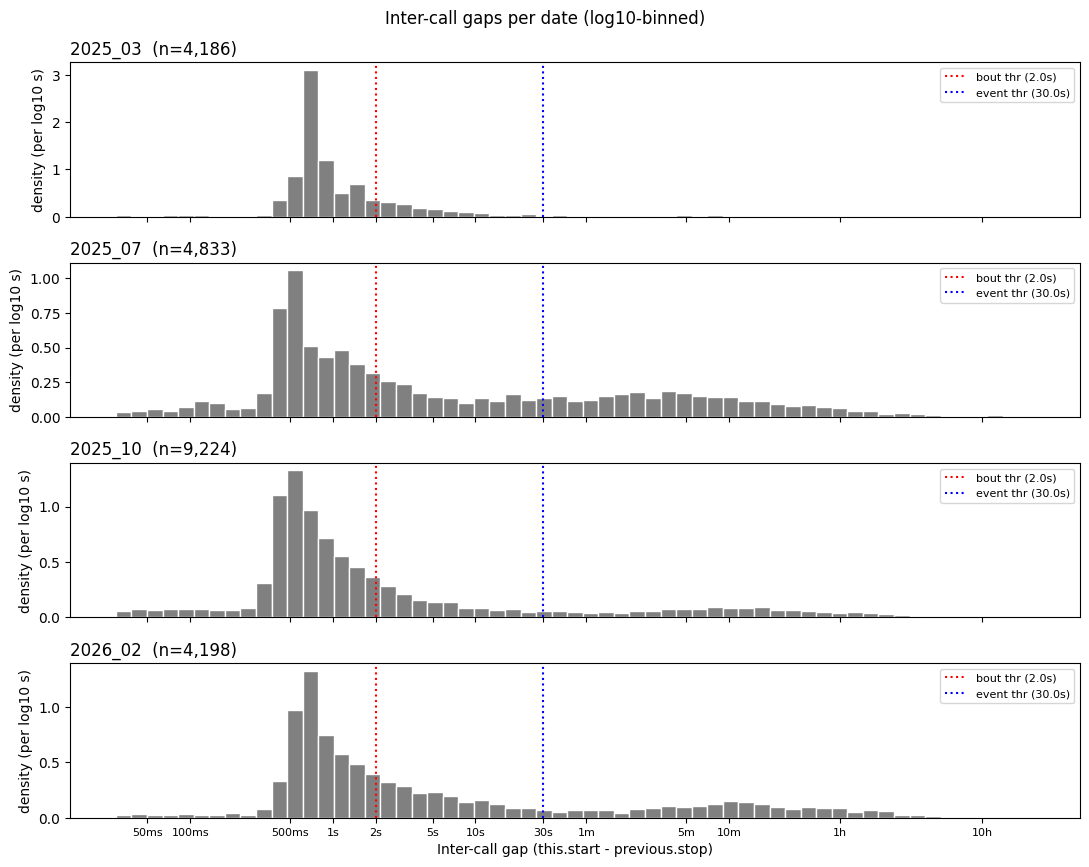

In [49]:
# All inter-call GAPS (calls["icg_s"]) per date.
#
# ICG = this.start - previous.stop (silent gap). We plot the GAP because
# the bout/event thresholds are defined on the gap, so the threshold lines
# are directly interpretable here. If you want start-to-start INTERVALS
# (period; 1/median = Hz), use calls["ici_s"] instead.
#
# We plot the histogram of log10(ICG). The convention for distributions
# that span many decades (here: tens of ms to hours). Density is then w.r.t.
# log10(x), so equal visible area = equal proportion of calls in that decade
# range.

MIN_PLOT_S = 0.03    # 30 ms - drop sub-30ms gaps (segmentation artifacts)

icg_s = calls["icg_s"].dropna()
n_total = len(icg_s)
icg_s = icg_s[icg_s >= MIN_PLOT_S]
print(f"ICG plot: showing {len(icg_s):,}/{n_total:,} gaps "
      f"(dropped {n_total - len(icg_s):,} gaps < {MIN_PLOT_S*1000:.0f} ms)")

# Log10-transform once, then use LINEAR bins on the transformed data.
log_icg = np.log10(icg_s)
bins = np.linspace(log_icg.min(), log_icg.max(), 60)

# Thresholds (both defined on the GAP - that's why we plot the gap here).
bout_thr  = ALARM_SCALES[0]["max_icg_s"]
event_thr = ALARM_SCALES[1]["max_icg_s"]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = calls[calls["date_folder"] == date]["icg_s"].dropna()
    sub = sub[sub >= MIN_PLOT_S]
    ax.hist(np.log10(sub), bins=bins, density=True, color="gray", edgecolor="white")
    ax.axvline(np.log10(bout_thr),  color="red",  linestyle=":", label=f"bout thr ({bout_thr}s)")
    ax.axvline(np.log10(event_thr), color="blue", linestyle=":", label=f"event thr ({event_thr}s)")
    ax.set_title(f"{date}  (n={len(sub):,})", loc="left")
    ax.set_ylabel("density (per log10 s)")
    ax.legend(loc="upper right", fontsize=8)

tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h", "10h"]
axes[-1].set_xticks(np.log10(tick_seconds))
axes[-1].set_xticklabels(tick_labels, fontsize=8)
axes[-1].set_xlabel("Inter-call gap (this.start - previous.stop)")

fig.suptitle("Inter-call gaps per date (log10-binned)")
fig.tight_layout()
save_fig(fig, "alarm_icg_per_date")
plt.show()

## Inter-bout gap per date

One scale up. `bouts_meta["gap_s"]` is the silent gap between consecutive bouts (`this_bout.start − previous_bout.stop`). By construction every value is ≥ 2 s (anything shorter would have been *within* the same bout).

The red dotted line marks the bout threshold (left edge — gaps can't be smaller). The blue dotted line marks the event threshold (30 s): gaps below it stay inside one event, gaps above it cross between events.

(For start-to-start **inter-bout intervals**, use `bouts_meta["interval_s"]`.)

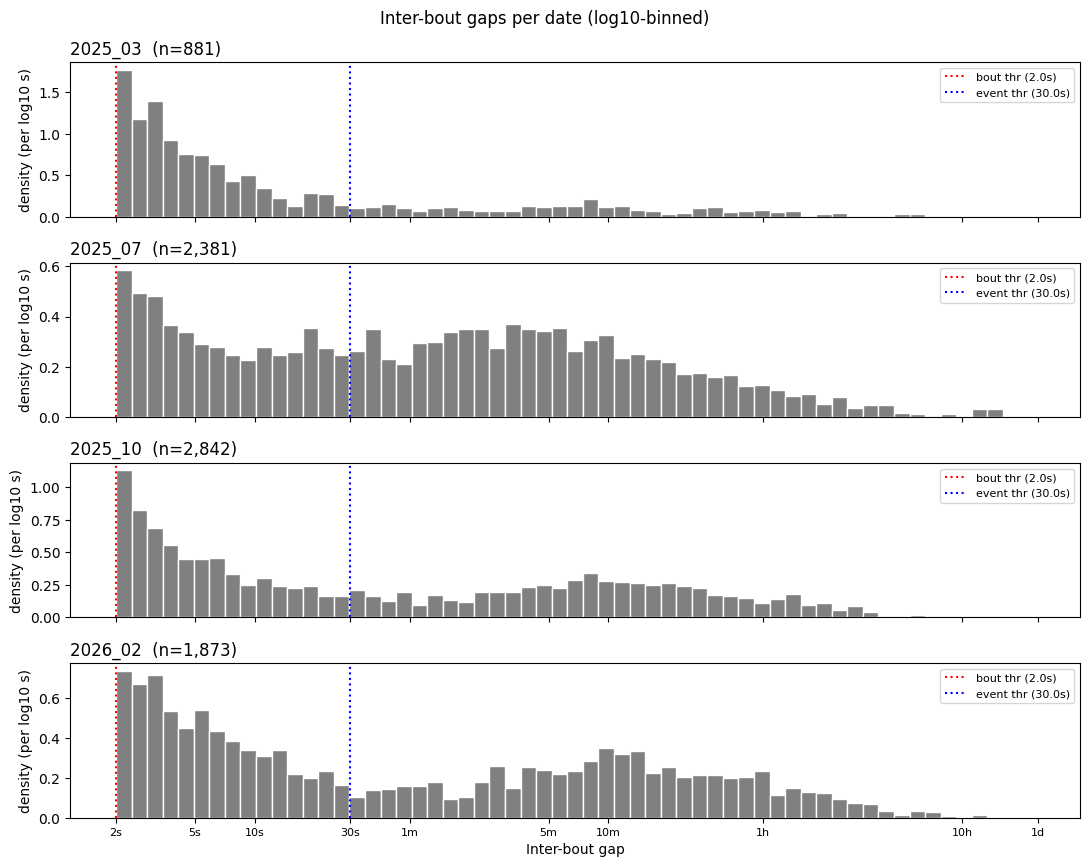

In [17]:
# Inter-bout gaps (gap_s on bouts_meta).
# gap_s = this_bout.start - previous_bout.stop. All values are >= bout
# threshold (2 s) by construction. The event threshold (30 s) separates
# gaps that stay within one event vs cross between events.
#
# Same log10-transform approach as the ICG plot: histogram of log10(gap_s)
# with linear bins. Density is then w.r.t. log10(x), so heavy tails stay visible.

ibg_s = bouts_meta["gap_s"].dropna()
ibg_s = ibg_s[ibg_s > 0]

log_ibg = np.log10(ibg_s)
bins = np.linspace(log_ibg.min(), log_ibg.max(), 60)

bout_thr  = ALARM_SCALES[0]["max_icg_s"]
event_thr = ALARM_SCALES[1]["max_icg_s"]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[bouts_meta["date_folder"] == date]["gap_s"].dropna()
    sub = sub[sub > 0]
    ax.hist(np.log10(sub), bins=bins, density=True, color="gray", edgecolor="white")
    ax.axvline(np.log10(bout_thr),  color="red",  linestyle=":", label=f"bout thr ({bout_thr}s)")
    ax.axvline(np.log10(event_thr), color="blue", linestyle=":", label=f"event thr ({event_thr}s)")
    ax.set_title(f"{date}  (n={len(sub):,})", loc="left")
    ax.set_ylabel("density (per log10 s)")
    ax.legend(loc="upper right", fontsize=8)

tick_seconds = [2, 5, 10, 30, 60, 300, 600, 3600, 36000, 86400]
tick_labels  = ["2s", "5s", "10s", "30s", "1m", "5m", "10m", "1h", "10h", "1d"]
axes[-1].set_xticks(np.log10(tick_seconds))
axes[-1].set_xticklabels(tick_labels, fontsize=8)
axes[-1].set_xlabel("Inter-bout gap")

fig.suptitle("Inter-bout gaps per date (log10-binned)")
fig.tight_layout()
save_fig(fig, "alarm_inter_bout_gap_per_date")
plt.show()

## Inter-event gap per date

Same idea, one scale coarser. Each row in `events_meta` carries `gap_s` = gap from the previous event's last call to this event's first call. All values are ≥ 30 s by construction.

(For start-to-start **inter-event intervals**, use `events_meta["interval_s"]`.)

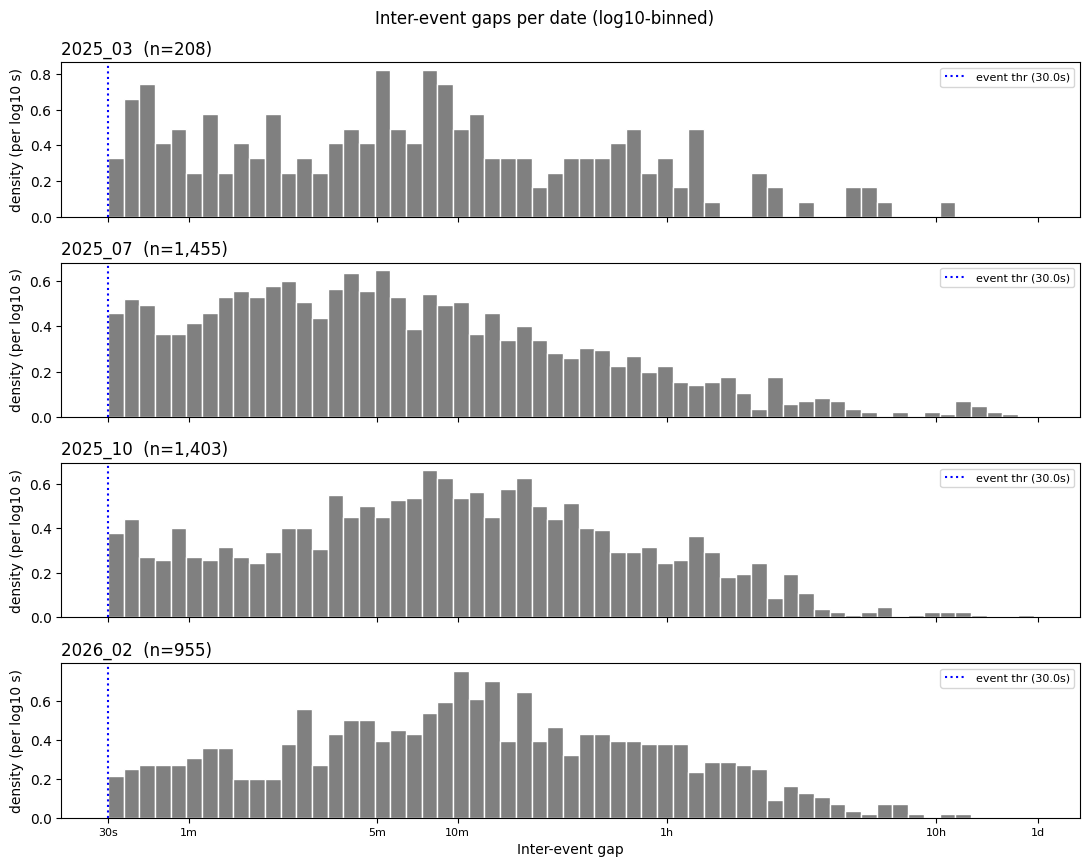

In [18]:
# Inter-event gaps (gap_s on events_meta).
# gap_s = this_event.start - previous_event.stop. All values are >= event
# threshold (30 s) by construction.
#
# Same log10-transform approach as the ICG / IBG plots.

ieg_s = events_meta["gap_s"].dropna()
ieg_s = ieg_s[ieg_s > 0]

log_ieg = np.log10(ieg_s)
bins = np.linspace(log_ieg.min(), log_ieg.max(), 60)

event_thr = ALARM_SCALES[1]["max_icg_s"]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = events_meta[events_meta["date_folder"] == date]["gap_s"].dropna()
    sub = sub[sub > 0]
    ax.hist(np.log10(sub), bins=bins, density=True, color="gray", edgecolor="white")
    ax.axvline(np.log10(event_thr), color="blue", linestyle=":", label=f"event thr ({event_thr}s)")
    ax.set_title(f"{date}  (n={len(sub):,})", loc="left")
    ax.set_ylabel("density (per log10 s)")
    ax.legend(loc="upper right", fontsize=8)

tick_seconds = [30, 60, 300, 600, 3600, 36000, 86400]
tick_labels  = ["30s", "1m", "5m", "10m", "1h", "10h", "1d"]
axes[-1].set_xticks(np.log10(tick_seconds))
axes[-1].set_xticklabels(tick_labels, fontsize=8)
axes[-1].set_xlabel("Inter-event gap")

fig.suptitle("Inter-event gaps per date (log10-binned)")
fig.tight_layout()
save_fig(fig, "alarm_inter_event_gap_per_date")
plt.show()

## Calls per hour, per date

Hourly rate of alarm calls across the day, averaged across all observed days, with the dark cycle shaded gray. One panel per date.

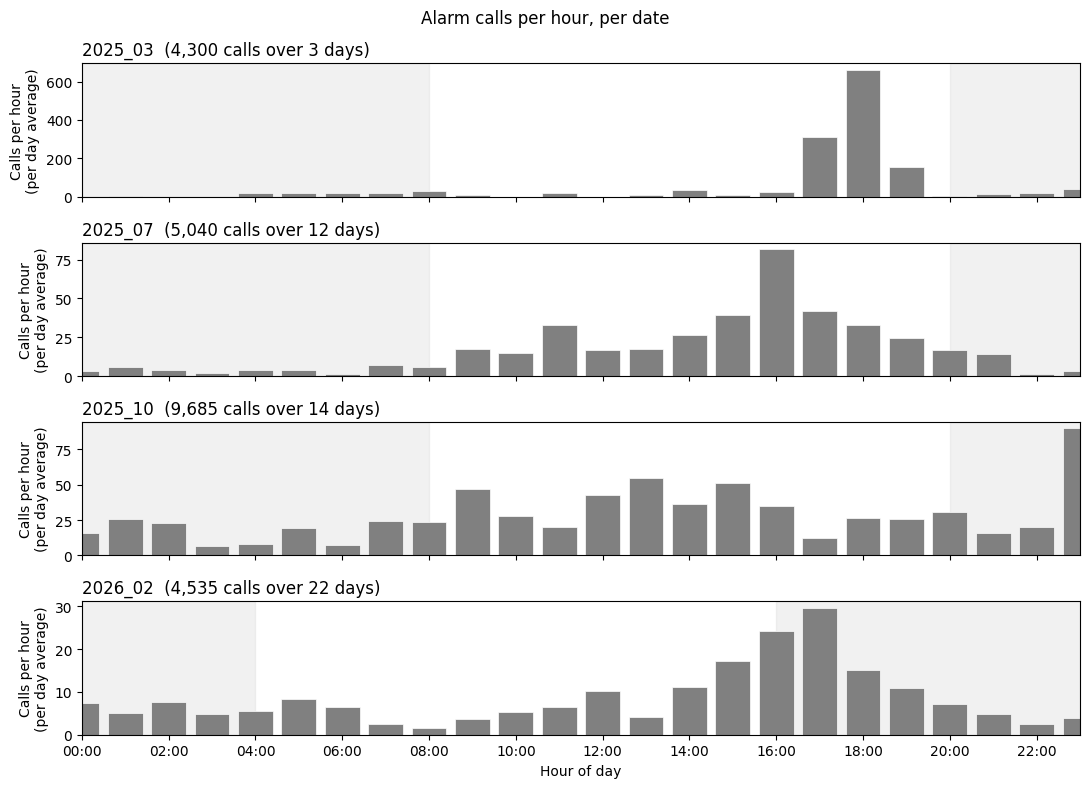

In [19]:
# Average alarm calls per hour-of-day, per date.
# Recipe (also used for bouts and events below):
#   1. For each date, get each row's hour-of-day from its timestamp.
#   2. Count rows per hour. Reindex to range(24) so empty hours show as 0.
#   3. Divide by the number of distinct days observed → average per day per hour.
#   4. Shade the dark-cycle hours (light hours stay white).

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.0 * len(DATES_TO_PLOT)),
    sharex=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = calls[calls["date_folder"] == date]
    if sub.empty:
        ax.set_axis_off()
        continue

    hours  = sub["start_time_real"].dt.hour
    n_days = sub["start_time_real"].dt.normalize().nunique()
    counts = hours.value_counts().reindex(range(24), fill_value=0)
    rate   = counts / n_days   # mean count per hour per day

    ax.bar(rate.index, rate.values, color="gray", edgecolor="white", linewidth=0.5)

    # Shade DARK hours (light hours stay white).
    light_start, light_end = LIGHT_OVERRIDES.get(date, LIGHT_DEFAULT)
    if light_start < light_end:
        # Normal case: light is a continuous window inside the day.
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24,  color="lightgray", alpha=0.3, zorder=0)
    else:
        # Light window wraps midnight (start > end). Shade the single dark block in between.
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(f"{date}  ({len(sub):,} calls over {n_days} days)", loc="left")
    ax.set_ylabel("Calls per hour\n(per day average)")

ticks = list(range(0, 25, 2))
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Hour of day")
axes[-1].set_xlim(0, 23)

fig.suptitle("Alarm calls per hour, per date")
fig.tight_layout()
save_fig(fig, "alarm_calls_per_hour_per_date")
plt.show()

## Bouts per hour, per date

Same shape, but counting **bouts** (one row per bout in `bouts_meta`) — each bar is the average number of bouts that *started* in that hour, across days.

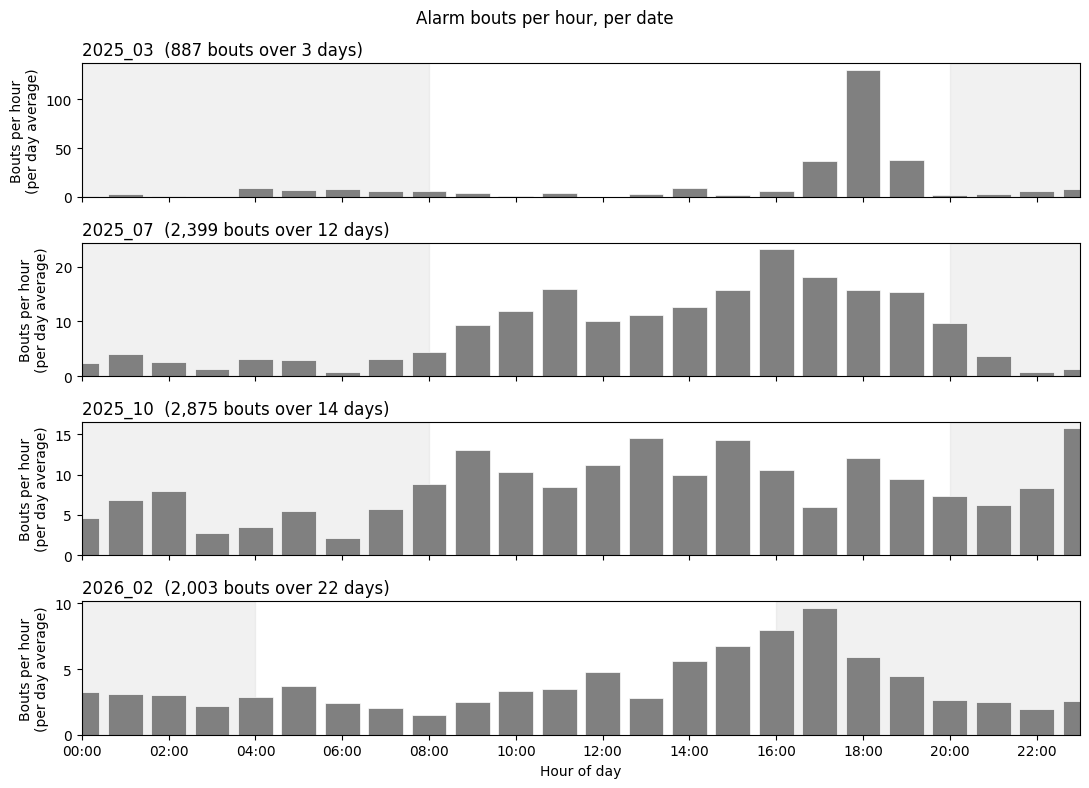

In [20]:
# Average bouts per hour-of-day, per date.
fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.0 * len(DATES_TO_PLOT)),
    sharex=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = bouts_meta[bouts_meta["date_folder"] == date]
    if sub.empty:
        ax.set_axis_off()
        continue

    hours  = sub["start_time"].dt.hour
    n_days = sub["start_time"].dt.normalize().nunique()
    counts = hours.value_counts().reindex(range(24), fill_value=0)
    rate   = counts / n_days

    ax.bar(rate.index, rate.values, color="gray", edgecolor="white", linewidth=0.5)

    # Shade DARK hours (light hours stay white).
    light_start, light_end = LIGHT_OVERRIDES.get(date, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24,  color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(f"{date}  ({len(sub):,} bouts over {n_days} days)", loc="left")
    ax.set_ylabel("Bouts per hour\n(per day average)")

ticks = list(range(0, 25, 2))
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Hour of day")
axes[-1].set_xlim(0, 23)

fig.suptitle("Alarm bouts per hour, per date")
fig.tight_layout()
save_fig(fig, "alarm_bouts_per_hour_per_date")
plt.show()

## Events per hour, per date

One row per event in `events_meta`. Each bar = events that started in that hour, averaged across days. Dark hours shaded.

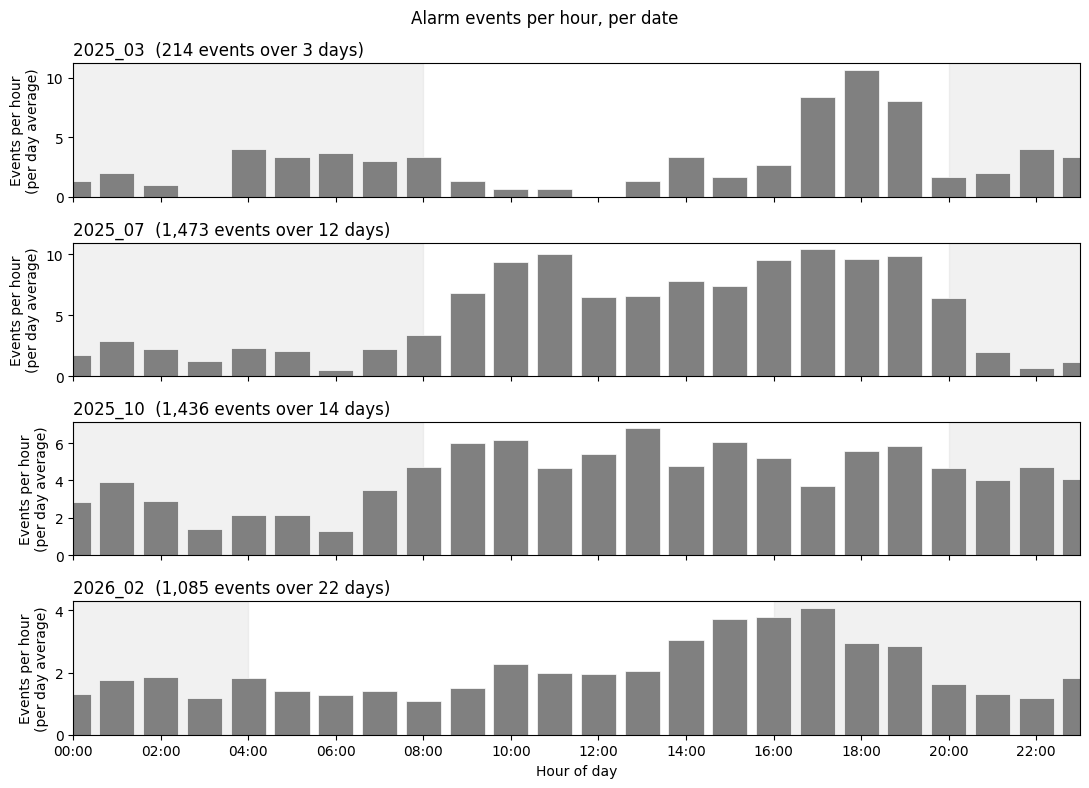

In [21]:
# Average events per hour-of-day, per date.
fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.0 * len(DATES_TO_PLOT)),
    sharex=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = events_meta[events_meta["date_folder"] == date]
    if sub.empty:
        ax.set_axis_off()
        continue

    hours  = sub["start_time"].dt.hour
    n_days = sub["start_time"].dt.normalize().nunique()
    counts = hours.value_counts().reindex(range(24), fill_value=0)
    rate   = counts / n_days

    ax.bar(rate.index, rate.values, color="gray", edgecolor="white", linewidth=0.5)

    # Shade DARK hours (light hours stay white).
    light_start, light_end = LIGHT_OVERRIDES.get(date, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24,  color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(f"{date}  ({len(sub):,} events over {n_days} days)", loc="left")
    ax.set_ylabel("Events per hour\n(per day average)")

ticks = list(range(0, 25, 2))
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Hour of day")
axes[-1].set_xlim(0, 23)

fig.suptitle("Alarm events per hour, per date")
fig.tight_layout()
save_fig(fig, "alarm_events_per_hour_per_date")
plt.show()

## CV of within-bout ICI per date

**CV** (coefficient of variation) = `std(ICI) / mean(ICI)`, computed per bout. Already stored in `bouts_meta["cv_ici"]` (start-to-start period-based). Measures within-bout rhythm regularity:

- `CV ≈ 0` → perfectly regular (every ICI the same)
- `CV = 1` → Poisson-like (exponentially distributed ICIs)
- `CV > 1` → more bursty than Poisson

Restrict to bouts with at least `MIN_CALLS_FOR_CV` calls so each per-bout CV is computed from enough samples to be meaningful.

(If you want the old `alarm_bouts_3` numbers exactly, use `cv_icg` instead — that's the gap-based version, which was what their `cv_ici` actually computed under the old naming.)

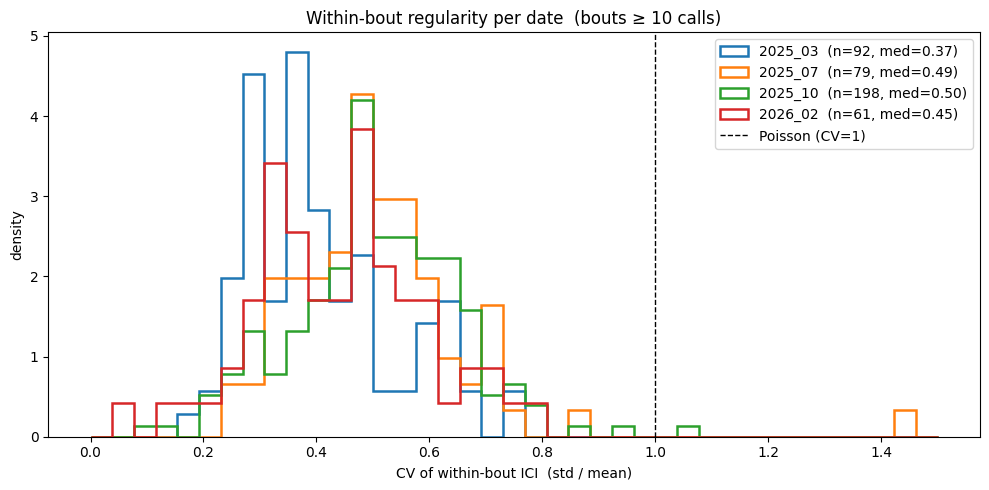

In [43]:
# CV of within-bout ICI per date.
# CV = std(ICI) / mean(ICI), computed per bout - already on bouts_meta as cv_ici.
# Reference line at CV=1 = Poisson-like irregularity.

# Restrict to bouts with enough calls that their per-bout CV is meaningful.
# (A bout with only 2 calls has 1 ICI -> std is NaN -> CV is NaN. A bout with 3
#  calls has 2 ICIs -> CV is technically defined but very noisy.)
MIN_CALLS_FOR_CV = 10

bins = np.linspace(0, 1.5, 40)

fig, ax = plt.subplots(figsize=(10, 5))

# One color per date (matplotlib's default cycle is fine here).
date_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(DATES_TO_PLOT)]

for date, color in zip(DATES_TO_PLOT, date_colors):
    sub = bouts_meta[
        (bouts_meta["date_folder"] == date)
        & (bouts_meta["bout_size"] >= MIN_CALLS_FOR_CV)
    ]["cv_ici"].dropna()
    if sub.empty:
        continue
    ax.hist(
        sub, bins=bins, histtype="step", linewidth=1.8, density=True, color=color,
        label=f"{date}  (n={len(sub):,}, med={sub.median():.2f})",
    )

ax.axvline(1.0, color="black", linestyle="--", linewidth=1.0, label="Poisson (CV=1)")
ax.set_xlabel("CV of within-bout ICI  (std / mean)")
ax.set_ylabel("density")
ax.set_title(f"Within-bout regularity per date  (bouts ≥ {MIN_CALLS_FOR_CV} calls)")
ax.legend()

fig.tight_layout()
save_fig(fig, f"alarm_within_bout_cv_ici_per_date_min{MIN_CALLS_FOR_CV}")
plt.show()

## Call duration trajectory within bouts

How does call duration change as a bout progresses? **Spaghetti plot**: one thin gray line per bout shows its own (paired) trajectory; the red line + envelope shows the population median ± IQR at each position.

Two caveats:
- **Selection bias at later positions.** Position `p` is computed only over bouts with at least `p` calls — so the right side of each panel reflects increasingly *long* (and therefore probably more intense) bouts. The legend reports the `n` of bouts contributing at the first and last visible position so the bias is visible.
- **Spaghetti is subsampled** (random `N_SPAGHETTI_MAX`) for visual clarity; the red median/IQR uses **all** bouts in the date.

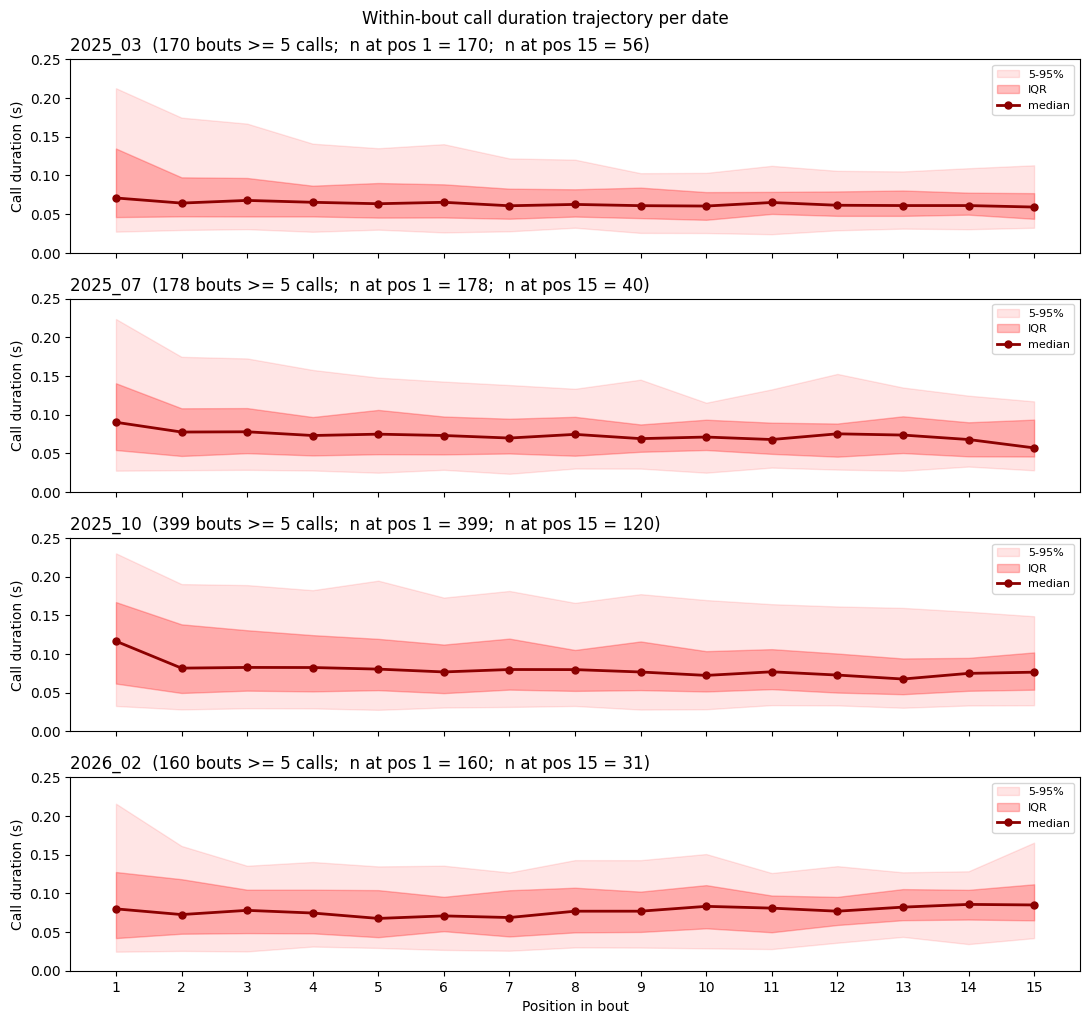

In [44]:
# Within-bout call duration trajectory, per date.
#
# Fan chart per date: median line + IQR (25-75%) band + 5-95% band. Each band
# is computed at every position across the bouts that reach that position
# (paired - each bout contributes its own trajectory to the stats).

MIN_SIZE = 5     # only "real" multi-call bouts (matches in_bout threshold)
MAX_POS  = 15    # cap the x-axis; most bouts don't reach this far

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.6 * len(DATES_TO_PLOT)),
    sharex=True, sharey=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = calls[
        (calls["date_folder"] == date)
        & (calls["bout_size"] >= MIN_SIZE)
        & (calls["bout_position"] <= MAX_POS)
    ]
    # Wide-format duration matrix: rows = bouts, cols = position, values = duration_sec.
    mat = sub.pivot(index="bout_id", columns="bout_position", values="duration_sec")
    if mat.empty:
        ax.set_axis_off()
        continue

    # Percentile bands and median - computed across ALL bouts at each position.
    p05    = mat.quantile(0.05, axis=0)
    p25    = mat.quantile(0.25, axis=0)
    median = mat.median(axis=0)
    p75    = mat.quantile(0.75, axis=0)
    p95    = mat.quantile(0.95, axis=0)
    n_per_pos = mat.notna().sum(axis=0)

    # Outer band: 5-95 percentile (light).
    ax.fill_between(median.index, p05, p95, color="red", alpha=0.10, label="5-95%")
    # Inner band: IQR (medium).
    ax.fill_between(median.index, p25, p75, color="red", alpha=0.25, label="IQR")
    # Median line (bold).
    ax.plot(median.index, median.values, "-o", color="darkred",
            linewidth=2, markersize=5, label="median")

    n_first = int(n_per_pos.iloc[0])
    n_last  = int(n_per_pos.iloc[-1])
    ax.set_title(
        f"{date}  ({mat.shape[0]:,} bouts >= {MIN_SIZE} calls;  "
        f"n at pos 1 = {n_first:,};  n at pos {int(median.index[-1])} = {n_last:,})",
        loc="left",
    )
    ax.set_ylabel("Call duration (s)")
    ax.legend(loc="upper right", fontsize=8)

# Tight linear y-axis - captures medians and most of the IQR/5-95 bands without
# wasting space on the extreme outlier tail.
axes[0].set_ylim(0, 0.25)
axes[-1].set_xticks(range(1, MAX_POS + 1))
axes[-1].set_xlabel("Position in bout")

fig.suptitle("Within-bout call duration trajectory per date")
fig.tight_layout()
save_fig(fig, "alarm_duration_trajectory_per_date")
plt.show()

## Acoustic feature trajectories within bouts

To capture the multi-feature signal from the spectrogram example (duration shrinks + upper harmonic disappears + call simplifies), we run `compute_features` on every call in a subsample of in_bout bouts. Then plot fan charts of each feature across `bout_position`, just like the duration trajectory above.

**Subsampling:** `compute_features` takes ~30–50 ms per call, so running on all 23 k alarm calls would be slow. We sample `N_BOUTS_PER_DATE` bouts per date (defaulting to 100), then keep all calls inside those bouts → roughly 2–3 k calls total → ~2 min runtime.

**Cluster only** — needs raw WAVs.

In [50]:
# Extract vocalpy features for every call in a subsample of in_bout bouts.
# Subsample because compute_features takes ~30-50 ms/call - extracting all
# 23 k alarm calls would take ~20 min. 100 bouts/date * ~7 calls/bout ~ 2800
# calls total, ~2 min runtime.
#
# PAD_SEC: load each call with a small symmetric buffer of audio on each side.
# Mitigates the segmenter occasionally cutting a call's tail (and possibly
# leading edge). Features (FM, pitch, PSD) are then computed over the full
# call. `duration_s` is overwritten with the segmenter's ORIGINAL call
# duration so the buffer doesn't inflate it.

N_BOUTS_PER_DATE = 100
SEED             = 0
PAD_SEC          = 0.01    # 10 ms each side

if HOST != "Linux":
    raise RuntimeError("Need raw WAVs - run on the cluster.")

rng = np.random.default_rng(SEED)
sampled_bouts_parts = []
for date in DATES_TO_PLOT:
    pool = bouts_meta[
        (bouts_meta["date_folder"] == date)
        & (bouts_meta["bout_kind"] == "in_bout")
    ]
    if pool.empty:
        continue
    n = min(N_BOUTS_PER_DATE, len(pool))
    sample = pool.sample(n, random_state=int(rng.integers(0, 1_000_000)))
    sampled_bouts_parts.append(sample)

sampled_bouts = pd.concat(sampled_bouts_parts)
sampled_calls = calls[calls["bout_id"].isin(sampled_bouts.index)].copy()
print(f"Sampled {len(sampled_bouts):,} bouts across {len(DATES_TO_PLOT)} dates "
      f"-> {len(sampled_calls):,} calls to extract features for.")
print(f"Using pad_sec = {PAD_SEC*1000:.0f} ms on each side of each call.")

records = []
for i, row in enumerate(sampled_calls.itertuples(index=False)):
    y, sr = load_call_slice(
        BASE_PROCESSED_AUDIO,
        row.date_folder, row.exp, row.channel, row.file_num,
        row.start_time_file_sec, row.stop_time_file_sec,
        pad_sec=PAD_SEC,
    )
    feats = compute_features(y, sr)
    # Override: duration_s should reflect the SEGMENTER's call duration,
    # not the padded audio. Other features (FM, pitch, PSD) keep their
    # padded-audio values - that's the whole point of padding.
    feats["duration_s"] = row.stop_time_file_sec - row.start_time_file_sec
    records.append({
        "bout_id":       row.bout_id,
        "bout_position": row.bout_position,
        "bout_size":     row.bout_size,
        "date_folder":   row.date_folder,
        **feats,
    })
    if (i + 1) % 500 == 0:
        print(f"  {i+1:,}/{len(sampled_calls):,}")

features_df = pd.DataFrame(records)
print(f"\nfeatures_df: {features_df.shape[0]:,} rows x {features_df.shape[1]} cols")
print(f"Per-date call counts:")
print(features_df.groupby("date_folder").size())
features_df.head()

Sampled 400 bouts across 4 dates -> 5,631 calls to extract features for.
Using pad_sec = 10 ms on each side of each call.
  500/5,631
  1,000/5,631
  1,500/5,631
  2,000/5,631
  2,500/5,631
  3,000/5,631
  3,500/5,631
  4,000/5,631
  4,500/5,631
  5,000/5,631
  5,500/5,631

features_df: 5,631 rows x 28 cols
Per-date call counts:
date_folder
2025_03    1929
2025_07    1082
2025_10    1344
2026_02    1276
dtype: int64


,bout_id,bout_position,bout_size,date_folder,duration_s,peak_freq_hz,start_pitch_hz,stop_pitch_hz,pitch_median_hz,max_pitch_hz,...,fm_slope_per_s,goodness_of_pitch_median,mean_s_hz,std_s_hz,skew_s,kurtosis_s,entropy_s,q1_hz,q2_hz,q3_hz
0,13,1,7,2025_03,0.188536,24944.309952,24399.398905,24903.149603,24988.931135,25271.858758,...,-1.379812,0.185509,25252.546854,4126.644152,5.023621,31.783150,0.308614,24414.062500,24658.203125,24902.343750
1,13,2,7,2025_03,0.169592,24912.298660,24550.926322,23903.589389,24637.024221,25115.800833,...,1.562328,0.174177,24818.836100,3825.164710,4.958920,37.652004,0.297709,24169.921875,24414.062500,24658.203125
2,13,3,7,2025_03,0.125688,24875.417673,24508.778337,24704.217029,24780.193411,25116.977027,...,-0.719365,0.176855,25506.027285,5558.638683,3.383081,16.761286,0.332584,24169.921875,24414.062500,24658.203125
3,13,4,7,2025_03,0.119160,25413.852725,24488.157910,24832.224357,24912.024250,25424.617040,...,-0.500908,0.183832,26226.038504,6958.572816,2.334484,10.173859,0.424256,24414.062500,24658.203125,25146.484375
4,13,5,7,2025_03,0.060672,25123.548469,25123.548469,24655.273609,25029.789616,25222.793001,...,3.479682,0.175794,25863.340504,6156.091819,2.642995,13.676753,0.325211,24658.203125,24902.343750,25146.484375


In [51]:
# Join event-scale info onto features_df so the same analyses can run at
# either scale. After this cell, features_df has both:
#   bout_id,  bout_position,  bout_size       (already from the extraction)
#   event_id, event_position, event_size      (added here)
#
# Caveat: features_df was built from bout-sampled calls (100 in_bout bouts per
# date), so the events represented here are a non-random subset. Good enough
# for a quick look; if results are interesting, re-extract by sampling events
# instead of bouts.

# Idempotent: drop any pre-existing event_* columns before merging.
features_df = features_df.drop(
    columns=[c for c in ("event_id", "event_position", "event_size")
             if c in features_df.columns]
)

events_info = (
    calls[["bout_id", "bout_position", "event_id", "event_position", "event_size"]]
)
features_df = features_df.merge(
    events_info, on=["bout_id", "bout_position"], how="left",
)

print(f"features_df now has {features_df.shape[1]} cols (added event_id/position/size).")
print(f"All rows have event info: {features_df['event_position'].notna().all()}")
print(f"\nUnique events in features_df, per date:")
print(features_df.groupby("date_folder")["event_id"].nunique())

features_df now has 31 cols (added event_id/position/size).
All rows have event info: True

Unique events in features_df, per date:
date_folder
2025_03    51
2025_07    70
2025_10    88
2026_02    74
Name: event_id, dtype: int64


### Verify the FM-rising effect: example bouts

The feature-trajectory plot above showed `fm_median` rising with `bout_position` across all 4 dates. To check this isn't a measurement artifact: pick one random multi-call bout per date (10–15 calls), show every call's spectrogram, and the FM trajectory below.

If the trend is real, you should be able to *see* later calls having more in-call frequency modulation (curvier energy lines on the spectrogram) than earlier ones.

/tmp/ipykernel_3684116/1277232969.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


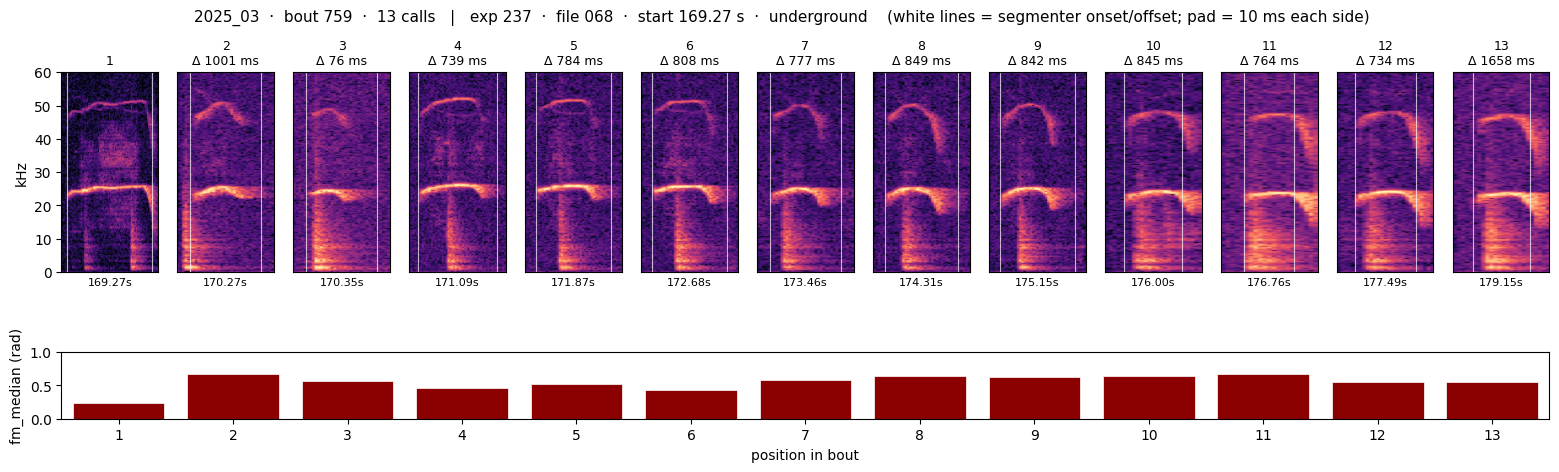

/tmp/ipykernel_3684116/1277232969.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


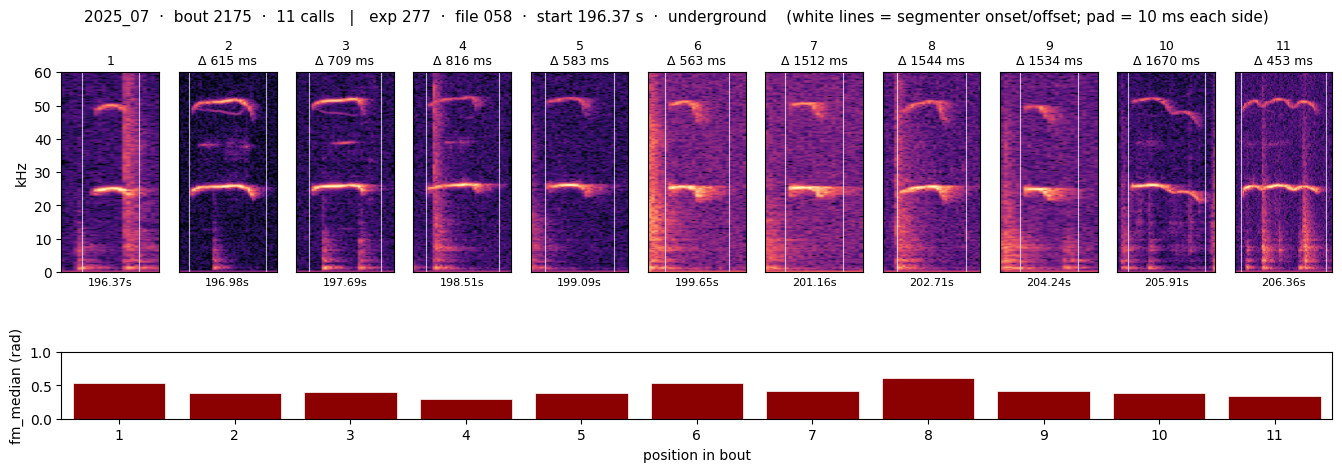

/tmp/ipykernel_3684116/1277232969.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


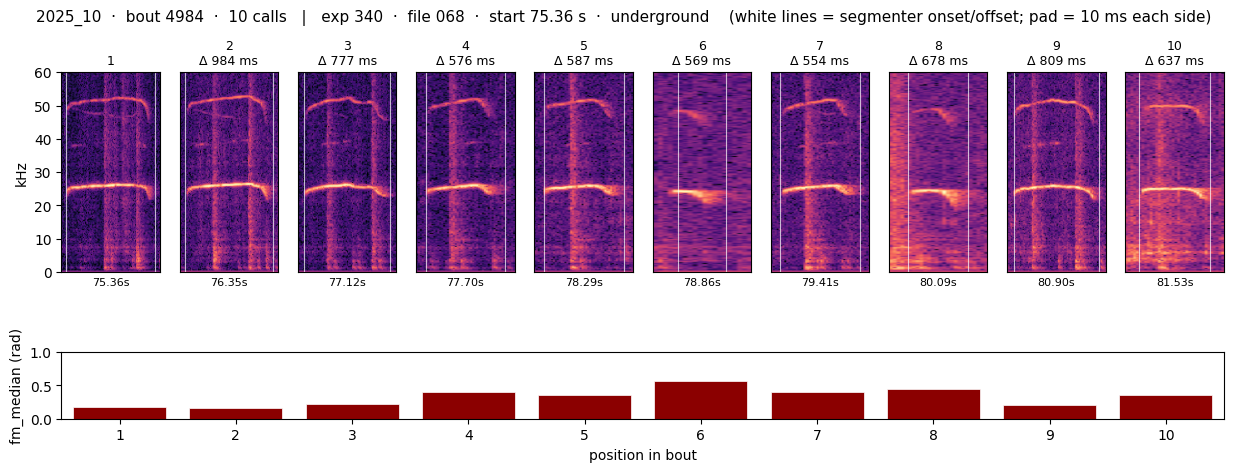

/tmp/ipykernel_3684116/1277232969.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


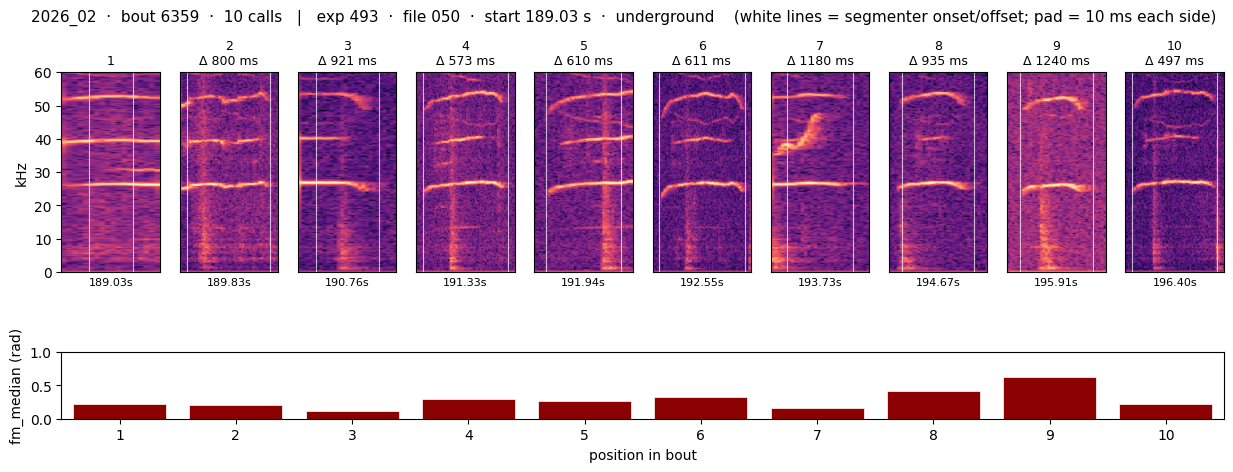

In [48]:
# One example bout per date - random pick from bouts of size 10-15 in features_df.
# For each: a strip of mini-spectrograms (one per call) plus an FM trajectory below.
#
# Audio is loaded with PAD_SEC of buffer on each side, so we can spot cases
# where the segmenter cut a call's tail. Two thin white vertical lines on
# each spectrogram show the segmenter's [start, stop] - energy outside those
# lines is "missing call" (or noise) that the feature extraction would have
# otherwise omitted.

import librosa

if HOST != "Linux":
    raise RuntimeError("Need raw WAVs - run on the cluster.")

EXAMPLE_SEED   = 0
SIZE_RANGE     = (10, 15)
SPEC_FREQ_LIM  = 60       # kHz
PAD_SEC        = 0.01     # match the feature-extraction buffer

rng_ex = np.random.default_rng(EXAMPLE_SEED)

example_bout_ids = []
for date in DATES_TO_PLOT:
    pool = features_df[
        (features_df["date_folder"] == date)
        & (features_df["bout_size"] >= SIZE_RANGE[0])
        & (features_df["bout_size"] <= SIZE_RANGE[1])
    ]["bout_id"].unique()
    if len(pool) == 0:
        print(f"  {date}: no bouts in size range {SIZE_RANGE}")
        continue
    example_bout_ids.append(int(rng_ex.choice(pool)))

for bout_id in example_bout_ids:
    bout_calls = (
        calls[calls["bout_id"] == bout_id]
        .sort_values("bout_position")
        .reset_index(drop=True)
    )
    n_calls = len(bout_calls)
    first   = bout_calls.iloc[0]
    date    = first["date_folder"]
    exp     = int(first["exp"])
    file_num     = int(first["file_num"])
    start_sec    = float(first["start_time_file_sec"])
    location     = first["assigned_location"]

    fig = plt.figure(figsize=(1.4 * n_calls + 1, 4.5))
    gs  = fig.add_gridspec(2, n_calls, height_ratios=[3, 1], hspace=0.6)
    spec_axes = [fig.add_subplot(gs[0, i]) for i in range(n_calls)]
    fm_ax     = fig.add_subplot(gs[1, :])

    for i, row in enumerate(bout_calls.itertuples(index=False)):
        # Load with buffer; we'll mark the segmenter's original boundaries.
        y, sr = load_call_slice(
            BASE_PROCESSED_AUDIO,
            row.date_folder, row.exp, row.channel, row.file_num,
            row.start_time_file_sec, row.stop_time_file_sec,
            pad_sec=PAD_SEC,
        )
        stft = librosa.stft(
            y, n_fft=SAT_PARAMS["n_fft"],
            hop_length=SAT_PARAMS["hop_length"], window="hann",
        )
        spec_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

        # The padded audio's time axis: 0 is the start of the padded read,
        # which (when not clipped by the file edge) is start_sec - PAD_SEC.
        # Compute the actual left-pad in ms (might be < PAD_SEC near file start).
        n_samples = len(y)
        total_ms  = n_samples / sr * 1000
        # Segmenter's call boundaries within the padded clip:
        call_dur_ms  = (row.stop_time_file_sec - row.start_time_file_sec) * 1000
        left_pad_ms  = (total_ms - call_dur_ms) * (PAD_SEC / (2 * PAD_SEC))  # equal split unless clipped
        # In practice the equal-split assumption is good enough away from file edges;
        # just use PAD_SEC*1000 directly:
        left_pad_ms  = PAD_SEC * 1000
        right_pad_ms = total_ms - call_dur_ms - left_pad_ms
        call_onset_ms  = left_pad_ms
        call_offset_ms = left_pad_ms + call_dur_ms

        ax = spec_axes[i]
        ax.imshow(
            spec_db, origin="lower", aspect="auto",
            extent=[0, total_ms, 0, sr / 2 / 1000],
            cmap="magma", vmin=-80, vmax=0,
        )
        ax.set_ylim(0, SPEC_FREQ_LIM)
        # Two white vertical lines = segmenter's [start, stop].
        # Energy outside these lines is in the buffer.
        ax.axvline(call_onset_ms,  color="white", lw=0.8, alpha=0.7)
        ax.axvline(call_offset_ms, color="white", lw=0.8, alpha=0.7)

        if i == 0:
            ax.set_title(f"{i + 1}", fontsize=9)
        else:
            ici_ms = row.ici_s * 1000
            ax.set_title(f"{i + 1}\nΔ {ici_ms:.0f} ms", fontsize=9)
        ax.set_xlabel(f"{row.start_time_file_sec:.2f}s", fontsize=8)
        ax.set_xticks([])
        if i > 0:
            ax.set_yticks([])
    spec_axes[0].set_ylabel("kHz")

    fm_row = (
        features_df[features_df["bout_id"] == bout_id]
        .sort_values("bout_position")[["bout_position", "fm_median"]]
    )
    fm_ax.bar(
        fm_row["bout_position"].values, fm_row["fm_median"].values,
        color="darkred", edgecolor="white", linewidth=0.5,
    )
    fm_ax.set_xticks(fm_row["bout_position"].values)
    fm_ax.set_xlim(0.5, n_calls + 0.5)
    fm_ax.set_ylim(0, max(1.0, fm_row["fm_median"].max() * 1.15))
    fm_ax.set_ylabel("fm_median (rad)")
    fm_ax.set_xlabel("position in bout")

    fig.suptitle(
        f"{date}  ·  bout {bout_id}  ·  {n_calls} calls   |   "
        f"exp {exp}  ·  file {file_num:03d}  ·  start {start_sec:.2f} s  ·  {location}    "
        f"(white lines = segmenter onset/offset; pad = {int(PAD_SEC*1000)} ms each side)",
        y=1.02, fontsize=11,
    )
    fig.tight_layout()
    plt.show()

## Duration vs pitch curvature, colored by position

Two of the position-sensitive features plotted against each other. If the within-bout trajectory is "flat-and-long → curvy-and-short", we should see calls form a diagonal cloud:

- **Top-right** (long duration, less negative / near-zero curvature) = position 1 calls (flat).
- **Bottom-left** (short duration, strongly negative curvature) = late-position calls (curvy ∩-shape).

The black line connects per-position medians so the average trajectory is visible across the cloud.

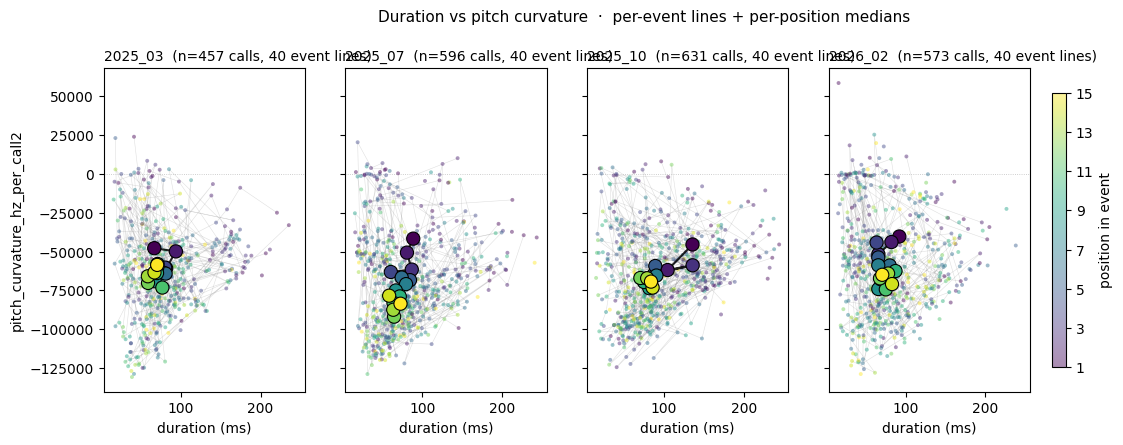

In [52]:
# Scatter: duration_s (x) vs pitch_curvature_hz_per_call2 (y), colored by position.
# Three layers (back-to-front):
#   1. Thin gray lines connecting calls within the same bout/event (subsampled).
#   2. Cloud of all calls, colored by position-in-scale.
#   3. Per-position medians + connecting line.
#
# Set SCALE = "bout" or "event" to switch which grouping the analysis uses.

SCALE = "event"     # <-- toggle between "bout" and "event"

id_col, pos_col, size_col = f"{SCALE}_id", f"{SCALE}_position", f"{SCALE}_size"

MAX_POS_SCATTER = 15
CAP_DUR_MS      = 250
N_GROUP_LINES   = 40        # subsampled per-group trajectories per panel
LINE_SEED       = 1

cmap = plt.get_cmap("viridis")
rng_line = np.random.default_rng(LINE_SEED)

fig, axes = plt.subplots(
    1, len(DATES_TO_PLOT),
    figsize=(3.6 * len(DATES_TO_PLOT), 4.2),
    sharex=True, sharey=True,
)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = features_df[
        (features_df["date_folder"] == date)
        & (features_df[pos_col] <= MAX_POS_SCATTER)
        & features_df["pitch_curvature_hz_per_call2"].notna()
    ].copy()
    sub["duration_ms"] = sub["duration_s"] * 1000
    sub = sub[sub["duration_ms"] <= CAP_DUR_MS]
    if sub.empty:
        ax.set_axis_off()
        continue

    # --- Layer 1: thin per-group lines (subsampled). ---
    group_ids = sub[id_col].unique()
    n_pick = min(N_GROUP_LINES, len(group_ids))
    picked = rng_line.choice(group_ids, size=n_pick, replace=False)
    for gid in picked:
        gdata = sub[sub[id_col] == gid].sort_values(pos_col)
        if len(gdata) < 2:
            continue
        ax.plot(
            gdata["duration_ms"], gdata["pitch_curvature_hz_per_call2"],
            "-", color="gray", linewidth=0.4, alpha=0.25, zorder=2,
        )

    # --- Layer 2: cloud of every call (colored by position). ---
    sc = ax.scatter(
        sub["duration_ms"], sub["pitch_curvature_hz_per_call2"],
        c=sub[pos_col],
        cmap=cmap, vmin=1, vmax=MAX_POS_SCATTER,
        s=8, alpha=0.45, edgecolor="none", zorder=4,
    )

    # --- Layer 3: per-position medians + connecting line. ---
    medians = []
    for pos in range(1, MAX_POS_SCATTER + 1):
        ps = sub[sub[pos_col] == pos]
        if len(ps) < 5:
            continue
        medians.append({
            "position":    pos,
            "duration_ms": ps["duration_ms"].median(),
            "curvature":   ps["pitch_curvature_hz_per_call2"].median(),
        })
    med_df = pd.DataFrame(medians)
    if not med_df.empty:
        ax.plot(med_df["duration_ms"], med_df["curvature"],
                "-", color="black", linewidth=1.5, alpha=0.85, zorder=9)
        ax.scatter(
            med_df["duration_ms"], med_df["curvature"],
            c=med_df["position"], cmap=cmap, vmin=1, vmax=MAX_POS_SCATTER,
            s=90, edgecolor="black", linewidth=0.8, zorder=10,
        )

    ax.set_title(f"{date}  (n={len(sub):,} calls, {n_pick} {SCALE} lines)",
                 fontsize=10, loc="left")
    ax.set_xlabel("duration (ms)")
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)

axes[0].set_ylabel("pitch_curvature_hz_per_call2")

cbar = fig.colorbar(sc, ax=axes, label=f"position in {SCALE}", pad=0.02, shrink=0.85)
cbar.set_ticks(range(1, MAX_POS_SCATTER + 1, 2))

fig.suptitle(
    f"Duration vs pitch curvature  ·  per-{SCALE} lines + per-position medians",
    y=1.02, fontsize=11,
)
save_fig(fig, f"alarm_duration_vs_curvature_per_{SCALE}")
plt.show()

## Binary decoder: is this call position 1?

Cleanest framing of "first-call-is-special": a binary classifier. For each call, can we predict — from acoustic features alone — whether it's the first call of its event (or bout)?

Why this should outperform the regression:
- The visual pattern in our scatter plots was a step, not a gradient: position 1 vs everything else. A binary target matches that.
- Position 1 has ~10% prevalence (one call per multi-call group), so we use `class_weight="balanced"` so the loss isn't dominated by the majority class.
- AUC is the right metric — threshold-free, robust to class imbalance.

Expected coefficient signs (inverted from the position-regression):
- `duration_s` **positive** (longer → position 1)
- `pitch_curvature_hz_per_call2` **positive** (less negative = flatter → position 1)
- `fm_median` **negative** (lower FM → position 1)

SCALE = 'event'.  2,267 calls, 135 positives (6.0%), 246 events.

Cross-validated AUC overall = 0.758

Per-date AUC:
  2025_03: AUC = 0.764  (n = 458, positives = 28)
  2025_07: AUC = 0.752  (n = 597, positives = 38)
  2025_10: AUC = 0.777  (n = 638, positives = 42)
  2026_02: AUC = 0.749  (n = 574, positives = 27)

Standardized logistic coefficients (positive = predicts position 1):
  pitch_curvature_hz_per_call2        +0.652
  fm_median                           -0.441
  duration_s                          +0.337
  entropy_s                           +0.195
  peak_freq_hz                        -0.039


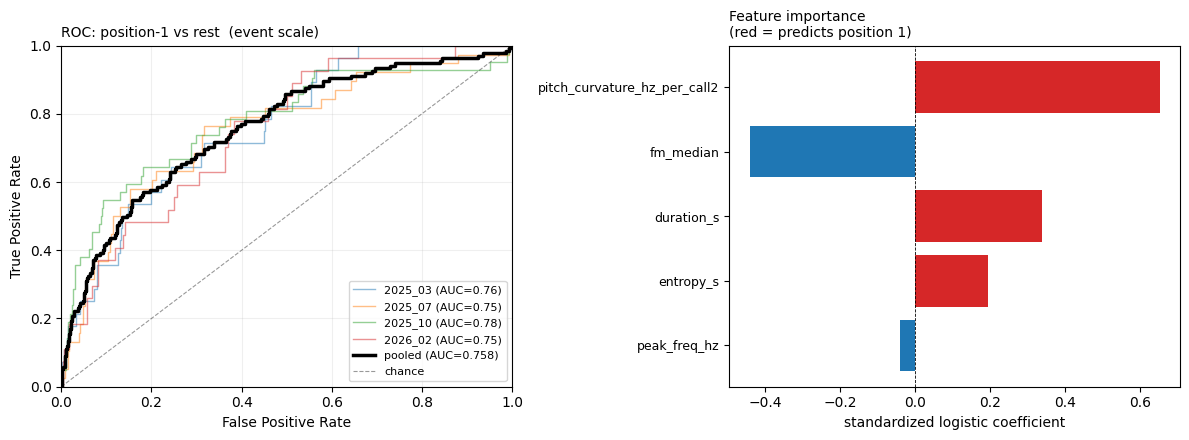

In [54]:
# Binary classifier: is this call position 1 of its bout/event?

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

SCALE   = "event"     # <-- toggle between "bout" and "event"
MAX_POS = 15

id_col, pos_col = f"{SCALE}_id", f"{SCALE}_position"

FEATURE_COLS = [
    "duration_s",
    "peak_freq_hz",
    "pitch_curvature_hz_per_call2",
    "entropy_s",
    "fm_median",
]

keep = features_df[
    features_df[pos_col] <= MAX_POS
][FEATURE_COLS + [pos_col, id_col, "date_folder"]].dropna()

X      = keep[FEATURE_COLS].values
y      = (keep[pos_col] == 1).astype(int).values    # binary target
groups = keep[id_col].values

print(f"SCALE = {SCALE!r}.  {len(keep):,} calls, {y.sum():,} positives "
      f"({y.mean()*100:.1f}%), {len(set(groups)):,} {SCALE}s.")

# Cross-validated logistic regression, grouped by id_col.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
cv = GroupKFold(n_splits=5)
proba = cross_val_predict(
    pipe, X, y, cv=cv, groups=groups, method="predict_proba",
)[:, 1]

# Overall AUC + per-date AUCs.
auc_overall = roc_auc_score(y, proba)
print(f"\nCross-validated AUC overall = {auc_overall:.3f}")

print("\nPer-date AUC:")
per_date_aucs = []
for date in DATES_TO_PLOT:
    mask = (keep["date_folder"] == date).values
    if mask.sum() < 10 or y[mask].sum() == 0:
        continue
    auc_d = roc_auc_score(y[mask], proba[mask])
    n     = mask.sum()
    n_pos = y[mask].sum()
    per_date_aucs.append((date, auc_d, n, n_pos))
    print(f"  {date}: AUC = {auc_d:.3f}  (n = {n:,}, positives = {n_pos:,})")

# Fit on all data for interpretable coefficients.
pipe.fit(X, y)
coefs = pipe.named_steps["logreg"].coef_.ravel()
print(f"\nStandardized logistic coefficients (positive = predicts position 1):")
for col, c in sorted(zip(FEATURE_COLS, coefs), key=lambda p: -abs(p[1])):
    print(f"  {col:35s} {c:+.3f}")

# Plots.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                         gridspec_kw={"width_ratios": [1.0, 1.0]})

# Left: ROC curve, with per-date curves overlaid faintly.
ax = axes[0]
for date, _, _, _ in per_date_aucs:
    mask = (keep["date_folder"] == date).values
    fpr_d, tpr_d, _ = roc_curve(y[mask], proba[mask])
    ax.plot(fpr_d, tpr_d, linewidth=1.0, alpha=0.5, label=f"{date} (AUC={per_date_aucs[[d[0] for d in per_date_aucs].index(date)][1]:.2f})")
fpr, tpr, _ = roc_curve(y, proba)
ax.plot(fpr, tpr, color="black", linewidth=2.5, label=f"pooled (AUC={auc_overall:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4, label="chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC: position-1 vs rest  ({SCALE} scale)", loc="left", fontsize=10)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.2)

# Right: coefficient bar chart.
ax = axes[1]
order = np.argsort(-np.abs(coefs))
sorted_cols  = [FEATURE_COLS[i] for i in order]
sorted_coefs = coefs[order]
bar_colors = ["#1f77b4" if c < 0 else "#d62728" for c in sorted_coefs]
ax.barh(range(len(sorted_coefs)), sorted_coefs, color=bar_colors)
ax.set_yticks(range(len(sorted_coefs)))
ax.set_yticklabels(sorted_cols, fontsize=9)
ax.axvline(0, color="black", linestyle="--", linewidth=0.6)
ax.set_xlabel("standardized logistic coefficient")
ax.set_title("Feature importance\n(red = predicts position 1)", loc="left", fontsize=10)
ax.invert_yaxis()

fig.tight_layout()
save_fig(fig, f"alarm_decoder_binary_position1_{SCALE}")
plt.show()

## First call vs N-th call: violin slopegraph

Paired comparison: every group (event or bout, depending on `SCALE`) that has both a position-1 call and a position-`COMPARE_POS` call contributes one paired observation. Violins show distributions; thin gray lines connect the two halves of each pair; per-panel Wilcoxon p is signed-rank on the paired differences.

Two knobs:
- `SCALE` — `"event"` (coarser, fewer groups but each is longer) vs `"bout"` (finer, more groups, each shorter).
- `COMPARE_POS` — which position to compare against.


In [ ]:
# Violin slopegraph: first call vs Nth call, paired within group.
# Self-contained (does not depend on the now-deleted Version-A cell).

from scipy.stats import wilcoxon

# ---- config ----
SCALE       = "event"   # "event" or "bout"
COMPARE_POS = 10        # change to 5 / 15 / etc.
ID_COL  = f"{SCALE}_id"
POS_COL = f"{SCALE}_position"

FEATURES_VIOLIN = [
    ("Duration (ms)",              "duration_s",                   lambda v: v * 1000),
    ("Pitch curvature (Hz/call²)", "pitch_curvature_hz_per_call2", lambda v: v),
    ("FM median (rad)",            "fm_median",                    lambda v: v),
]

def stars(p):
    if np.isnan(p): return ""
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return "n.s."

# ---- Build paired table: one row per group that has BOTH pos-1 and pos-N ----
records = []
for group_id, gdata in features_df.groupby(ID_COL):
    g_indexed = gdata.set_index(POS_COL)
    if 1 not in g_indexed.index or COMPARE_POS not in g_indexed.index:
        continue
    first_row = g_indexed.loc[1]
    nth_row   = g_indexed.loc[COMPARE_POS]
    if isinstance(first_row, pd.DataFrame): first_row = first_row.iloc[0]
    if isinstance(nth_row,   pd.DataFrame): nth_row   = nth_row.iloc[0]
    rec = {ID_COL: group_id, "date_folder": gdata["date_folder"].iloc[0]}
    for _, col, scale in FEATURES_VIOLIN:
        rec[f"{col}_first"] = scale(first_row[col])
        rec[f"{col}_nth"]   = scale(nth_row[col])
    records.append(rec)
paired_B = pd.DataFrame(records).dropna()
print(f"{SCALE}-scale, first vs pos {COMPARE_POS}: {len(paired_B)} {SCALE}s with both positions.")

# ---- Plot ----
fig, axes = plt.subplots(
    len(FEATURES_VIOLIN), len(DATES_TO_PLOT),
    figsize=(2.6 * len(DATES_TO_PLOT), 2.8 * len(FEATURES_VIOLIN)),
    sharey="row",
)

for r, (ylabel, col, _) in enumerate(FEATURES_VIOLIN):
    for c, date in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        sub = paired_B[paired_B["date_folder"] == date]
        if sub.empty:
            ax.set_axis_off()
            continue
        firsts = sub[f"{col}_first"].values
        nths   = sub[f"{col}_nth"].values

        parts = ax.violinplot(
            [firsts, nths], positions=[0, 1],
            widths=0.75, showmeans=False, showmedians=True,
        )
        for pc, color in zip(parts["bodies"], ["#d62728", "#1f77b4"]):
            pc.set_facecolor(color)
            pc.set_alpha(0.45)

        # Paired connectors + endpoint dots.
        for f_val, n_val in zip(firsts, nths):
            ax.plot([0, 1], [f_val, n_val], "-",
                    color="gray", alpha=0.2, linewidth=0.4, zorder=2)
        ax.scatter([0]*len(firsts), firsts, s=8,
                   color="#d62728", alpha=0.5, zorder=3, edgecolor="none")
        ax.scatter([1]*len(nths), nths, s=8,
                   color="#1f77b4", alpha=0.5, zorder=3, edgecolor="none")

        diff = firsts - nths
        try:
            _, p = wilcoxon(diff)
        except ValueError:
            p = float("nan")
        med_diff = np.median(diff)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["pos 1", f"pos {COMPARE_POS}"], fontsize=9)
        ax.set_xlim(-0.6, 1.6)
        if c == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if r == 0:
            ax.set_title(f"{date}  (n={len(sub)})", fontsize=10)
        ax.text(0.5, 0.97,
                f"Δmed = {med_diff:+.2f}\np = {p:.1e} {stars(p)}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8)

fig.suptitle(f"First call vs call at position {COMPARE_POS}  ({SCALE} scale)",
             y=1.02, fontsize=12)
fig.tight_layout()
save_fig(fig, f"alarm_violin_first_vs_pos{COMPARE_POS}_{SCALE}")
plt.show()


### Sweep N: which position-N gives the biggest contrast with position 1?

Instead of picking one N by eye, compute the **effect size (Cohen's d)** between
pos-1 calls and pos-N calls for every N in 2-15, separately for each feature.
Plot |Cohen's d| vs N; peak N tells you where the feature reaches its largest
opener-vs-mid-event separation.

In [ ]:
# Sweep N=2..15 for the paired comparison and pick the most informative
# position per feature. Uses *paired* within-group comparisons (same convention
# as the violin cell above).

from scipy.stats import wilcoxon

SCALE = "event"   # match the violin cell - "event" or "bout"
ID_COL  = f"{SCALE}_id"
POS_COL = f"{SCALE}_position"

SWEEP_FEATURES = [
    "duration_s",
    "pitch_curvature_hz_per_call2",
    "fm_median",
    "fm_early",
    "fm_late",
]
N_VALUES = list(range(2, 16))

records = []
for feat in SWEEP_FEATURES:
    for n in N_VALUES:
        diffs = []
        for group_id, gdata in features_df.groupby(ID_COL):
            g = gdata.set_index(POS_COL)
            if 1 not in g.index or n not in g.index:
                continue
            r1, rn = g.loc[1], g.loc[n]
            if isinstance(r1, pd.DataFrame): r1 = r1.iloc[0]
            if isinstance(rn, pd.DataFrame): rn = rn.iloc[0]
            v1, vn = r1[feat], rn[feat]
            if pd.isna(v1) or pd.isna(vn):
                continue
            diffs.append(vn - v1)
        if len(diffs) < 5:
            continue
        diffs = np.array(diffs)
        sd = diffs.std(ddof=1)
        d_paired = diffs.mean() / sd if sd > 0 else np.nan
        try:
            _, p = wilcoxon(diffs)
        except ValueError:
            p = np.nan
        records.append({
            "feature":   feat,
            "N":         n,
            "cohen_dz":  d_paired,
            "abs_dz":    abs(d_paired),
            "p":         p,
            "n_groups":  len(diffs),
        })

sweep_df = pd.DataFrame(records)

# ---- Plot ----
fig, (ax, ax_n) = plt.subplots(
    2, 1, figsize=(10, 5.4),
    gridspec_kw={"height_ratios": [3, 1]}, sharex=True,
)

feat_colors = dict(zip(SWEEP_FEATURES, plt.cm.tab10(range(len(SWEEP_FEATURES)))))
for feat in SWEEP_FEATURES:
    sub = sweep_df[sweep_df["feature"] == feat].sort_values("N")
    if sub.empty:
        continue
    ax.plot(sub["N"], sub["abs_dz"], "-o", color=feat_colors[feat],
            label=feat, linewidth=1.5, markersize=5)
    peak_row = sub.loc[sub["abs_dz"].idxmax()]
    ax.scatter(peak_row["N"], peak_row["abs_dz"],
               color=feat_colors[feat], s=140, edgecolor="black",
               linewidth=1.2, zorder=10)
    ax.annotate(f"N={int(peak_row['N'])}",
                (peak_row["N"], peak_row["abs_dz"]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=8, color=feat_colors[feat], va="center")

ax.set_ylabel("|Cohen's $d_z$|  (paired, pos-N vs pos-1)")
ax.set_title(f"Paired effect size of pos-1 vs pos-N across the {SCALE}")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)

n_by_N = sweep_df.groupby("N")["n_groups"].max()
ax_n.bar(n_by_N.index, n_by_N.values, color="gray", alpha=0.7)
ax_n.set_xlabel(f"N (position compared against position 1)")
ax_n.set_ylabel(f"# paired {SCALE}s")
ax_n.set_xticks(N_VALUES)
ax_n.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_fig(fig, f"alarm_pos1_vs_posN_effect_sweep_paired_{SCALE}")
plt.show()

print(f"\nBest N per feature ({SCALE} scale, largest paired |Cohen's d_z|):")
best = sweep_df.loc[sweep_df.groupby("feature")["abs_dz"].idxmax()]
print(best[["feature", "N", "cohen_dz", "p", "n_groups"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3g}"))


## Event-opener vs mid-event bout opener: state or motor?

The bout-scale effect being roughly half the event-scale effect suggests the
"first call is special" phenomenon isn't a generic motor reset that fires at
the start of every bout. To test directly:

For each event with **>= 2 bouts**, compare:
- **Red**: the event-opener (first call of the first bout, i.e. event-position 1).
- **Orange**: the first call of a later bout in the same event (paired within
  event by taking the median across all `bout_position=1` calls at
  `event_position > 1`).

Both are "first call of a bout" in motor terms. Only the red one is also the
"first call of the event." If they're indistinguishable -> motor reset. If red
is reliably more opener-like -> event-state gates the effect.

**Duration only here** — uses the full `calls` table (every call, no sampling)
so N is maximal. If duration shows the effect, we can re-extract features for
this event subset to test pitch curvature and FM too.


In [ ]:
# Event-opener vs mid-event bout-opener — duration-only version.
# Uses the full `calls` table (no feature-extraction sampling), so N is maximal.
# Pitch curvature and FM are skipped here; if duration shows a signal we can
# re-extract features for events with >=2 bouts to test those too.

from scipy.stats import wilcoxon

def stars(p):
    if np.isnan(p): return ""
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return "n.s."

# Compute call duration in seconds if not already present.
if "duration_s" not in calls.columns:
    calls = calls.assign(
        duration_s=calls["stop_time_file_sec"] - calls["start_time_file_sec"]
    )

# Build per-event paired rows using duration only.
records = []
for ev_id, ev_data in calls.groupby("event_id"):
    opener_rows = ev_data[(ev_data["bout_position"] == 1) &
                          (ev_data["event_position"] == 1)]
    mid_bout_rows = ev_data[(ev_data["bout_position"] == 1) &
                            (ev_data["event_position"] > 1)]
    if opener_rows.empty or mid_bout_rows.empty:
        continue
    opener = opener_rows.iloc[0]
    records.append({
        "event_id":    ev_id,
        "date_folder": ev_data["date_folder"].iloc[0],
        "opener_ms":   opener["duration_s"] * 1000,
        "midbout_ms":  mid_bout_rows["duration_s"].median() * 1000,
    })
paired_state = pd.DataFrame(records).dropna()
print(f"Events with both event-opener and >= 1 mid-event bout: {len(paired_state)}")
print(f"Per date:\n{paired_state.groupby('date_folder').size().to_string()}")

# ---- Plot: 1 row (duration), 4 cols (dates) ----
fig, axes = plt.subplots(1, len(DATES_TO_PLOT),
                         figsize=(2.8 * len(DATES_TO_PLOT), 3.5),
                         sharey=True)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = paired_state[paired_state["date_folder"] == date]
    if sub.empty:
        ax.set_axis_off()
        continue
    openers  = sub["opener_ms"].values
    midbouts = sub["midbout_ms"].values

    parts = ax.violinplot(
        [openers, midbouts], positions=[0, 1],
        widths=0.75, showmeans=False, showmedians=True,
    )
    for pc, color in zip(parts["bodies"], ["#d62728", "#ff7f0e"]):
        pc.set_facecolor(color); pc.set_alpha(0.45)

    for o_val, m_val in zip(openers, midbouts):
        ax.plot([0, 1], [o_val, m_val], "-",
                color="gray", alpha=0.2, linewidth=0.4, zorder=2)
    ax.scatter([0]*len(openers), openers, s=8,
               color="#d62728", alpha=0.5, zorder=3, edgecolor="none")
    ax.scatter([1]*len(midbouts), midbouts, s=8,
               color="#ff7f0e", alpha=0.5, zorder=3, edgecolor="none")

    diff = openers - midbouts
    try:
        _, p = wilcoxon(diff)
    except ValueError:
        p = float("nan")
    med_diff = np.median(diff)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["event\nopener", "mid-evt\nbout-1"], fontsize=9)
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(f"{date}  (n={len(sub)})", fontsize=10)
    ax.text(0.5, 0.97,
            f"Δmed = {med_diff:+.1f} ms\np = {p:.1e} {stars(p)}",
            transform=ax.transAxes, ha="center", va="top", fontsize=9)

axes[0].set_ylabel("Duration (ms)", fontsize=10)
fig.suptitle(
    "Event-opener vs mid-event bout-opener  ·  duration only  ·  paired within event",
    y=1.02, fontsize=12,
)
fig.tight_layout()
save_fig(fig, "alarm_violin_event_opener_vs_mid_event_bout_duration")
plt.show()


### Same test, all three features: re-extract for events with >=2 bouts

The duration-only result is solid. To check whether pitch curvature and FM
show the same state-gating, we need acoustic features for the event-opener
and mid-event bout-1 calls — which are mostly absent from `features_df` (random
bout sampling). This cell re-extracts features for exactly those calls
(targeted, much smaller than the original ~20-min full-corpus job), then
runs the same paired comparison on three features at once.

Expected runtime: ~2-3 minutes (extracts features for ~3-4 k calls).

In [ ]:
# Targeted feature extraction for the state-vs-motor test.
# Only the calls we need: event-opener (1 per event) + every mid-event bout-1
# call (1+ per event with >= 2 bouts).

from vocalization_analysis.acoustic_features import compute_features, load_call_slice

if HOST != "Linux":
    raise RuntimeError("Need raw WAVs - run on the cluster.")

# Identify the calls to extract.
target_mask = (
    (calls["bout_position"] == 1)
    & (
        (calls["event_position"] == 1)                                  # openers
        | (calls.groupby("event_id")["bout_position"].transform("count") > 1)  # placeholder
    )
)
# Cleaner: just take all calls with bout_position==1; we'll filter by event later.
target_calls = calls[calls["bout_position"] == 1].copy()

# Keep only events that have BOTH an event-opener and at least one mid-event bout-1.
have_opener = set(target_calls.loc[target_calls["event_position"] == 1, "event_id"])
have_midbout = set(target_calls.loc[target_calls["event_position"] > 1, "event_id"])
events_with_both = have_opener & have_midbout
target_calls = target_calls[target_calls["event_id"].isin(events_with_both)].copy()

print(f"Events with both event-opener and >=1 mid-event bout: {len(events_with_both)}")
print(f"Calls to extract features for: {len(target_calls):,}")
print(f"Estimated runtime at 40 ms/call: ~{len(target_calls) * 0.04 / 60:.1f} min")

PAD_SEC = 0.01
records = []
for i, row in enumerate(target_calls.itertuples(index=False)):
    try:
        y, sr = load_call_slice(
            BASE_PROCESSED_AUDIO,
            row.date_folder, row.exp, row.channel, row.file_num,
            row.start_time_file_sec, row.stop_time_file_sec,
            pad_sec=PAD_SEC,
        )
        feats = compute_features(y, sr)
        feats["duration_s"] = row.stop_time_file_sec - row.start_time_file_sec
        records.append({
            "event_id":       row.event_id,
            "event_position": row.event_position,
            "bout_id":        row.bout_id,
            "bout_position":  row.bout_position,
            "date_folder":    row.date_folder,
            **feats,
        })
    except Exception as e:
        if i < 5:
            print(f"  failed at i={i}: {e}")
    if (i + 1) % 500 == 0:
        print(f"  {i+1:,}/{len(target_calls):,}")

features_state_df = pd.DataFrame(records)
print(f"\nExtracted features: {len(features_state_df):,} rows x "
      f"{features_state_df.shape[1]} cols")


**Plot**: same recipe as the duration-only version, now with three features.

In [ ]:
# Paired state-vs-motor violin slopegraph on the targeted extraction.
# Uses features_state_df from the extraction cell above.

from scipy.stats import wilcoxon

FEATURES_STATE_VIOLIN = [
    ("Duration (ms)",              "duration_s",                   lambda v: v * 1000),
    ("Pitch curvature (Hz/call²)", "pitch_curvature_hz_per_call2", lambda v: v),
    ("FM median (rad)",            "fm_median",                    lambda v: v),
]

def stars(p):
    if np.isnan(p): return ""
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return "n.s."

records_p = []
for ev_id, ev_data in features_state_df.groupby("event_id"):
    opener_rows = ev_data[ev_data["event_position"] == 1]
    mid_bout_rows = ev_data[ev_data["event_position"] > 1]
    if opener_rows.empty or mid_bout_rows.empty:
        continue
    opener = opener_rows.iloc[0]
    rec = {"event_id": ev_id, "date_folder": ev_data["date_folder"].iloc[0]}
    for _, col, scale in FEATURES_STATE_VIOLIN:
        rec[f"{col}_opener"]  = scale(opener[col])
        rec[f"{col}_midbout"] = scale(mid_bout_rows[col].median())
    records_p.append(rec)
paired_state_full = pd.DataFrame(records_p).dropna()
print(f"Paired events with feature data: {len(paired_state_full)}")
print(f"Per date:\n{paired_state_full.groupby('date_folder').size().to_string()}")

# Plot 3 features x 4 dates.
fig, axes = plt.subplots(
    len(FEATURES_STATE_VIOLIN), len(DATES_TO_PLOT),
    figsize=(2.8 * len(DATES_TO_PLOT), 2.8 * len(FEATURES_STATE_VIOLIN)),
    sharey="row",
)

for r, (ylabel, col, _) in enumerate(FEATURES_STATE_VIOLIN):
    for c, date in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        sub = paired_state_full[paired_state_full["date_folder"] == date]
        if sub.empty:
            ax.set_axis_off()
            continue
        openers  = sub[f"{col}_opener"].values
        midbouts = sub[f"{col}_midbout"].values

        parts = ax.violinplot(
            [openers, midbouts], positions=[0, 1],
            widths=0.75, showmeans=False, showmedians=True,
        )
        for pc, color in zip(parts["bodies"], ["#d62728", "#ff7f0e"]):
            pc.set_facecolor(color); pc.set_alpha(0.45)

        for o_val, m_val in zip(openers, midbouts):
            ax.plot([0, 1], [o_val, m_val], "-",
                    color="gray", alpha=0.15, linewidth=0.3, zorder=2)
        ax.scatter([0]*len(openers), openers, s=6,
                   color="#d62728", alpha=0.4, zorder=3, edgecolor="none")
        ax.scatter([1]*len(midbouts), midbouts, s=6,
                   color="#ff7f0e", alpha=0.4, zorder=3, edgecolor="none")

        diff = openers - midbouts
        try:
            _, p = wilcoxon(diff)
        except ValueError:
            p = float("nan")
        med_diff = np.median(diff)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["event\nopener", "mid-evt\nbout-1"], fontsize=8)
        ax.set_xlim(-0.6, 1.6)
        if c == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if r == 0:
            ax.set_title(f"{date}  (n={len(sub)})", fontsize=10)
        ax.text(0.5, 0.97,
                f"Δmed = {med_diff:+.2f}\np = {p:.1e} {stars(p)}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8)

fig.suptitle(
    "Event-opener vs mid-event bout-opener  ·  all three features  ·  paired within event",
    y=1.02, fontsize=12,
)
fig.tight_layout()
save_fig(fig, "alarm_violin_state_vs_motor_all_features")
plt.show()


## Spectrogram-pair similarity vs position lag

Theory-free test: does call shape drift continuously through an event?

For every event, compute the log-mel spectrogram of each call (time-normalized
to a fixed frame count so all calls live in the same shape space). Then for
each pair of calls (i, j) in the same event, compute the cosine similarity
between their normalized spectrograms. Plot mean similarity as a function of
position-lag `|j - i|`.

- **Falling curve**: calls are drifting through shape space — adjacent calls
  more similar than far-apart calls. Real continuous gradient.
- **Flat curve**: calls in the same event are equally similar regardless of
  position-gap. No continuous drift.
- **Step at lag = 1 then flat**: the only "drift" is the position-1 vs rest
  step (pairs involving position 1 vs not).

Audio-loading step is ~30 s on the cluster.

Calls with audio coords: 5,631
Events with >= 3 calls (positions 1-10): 221
  500/3,596
  1,000/3,596
  1,500/3,596
  2,000/3,596
  2,500/3,596
  3,000/3,596
  3,500/3,596
Computed specs for 3,596 calls (0 failed)

Total pairs: 6,110


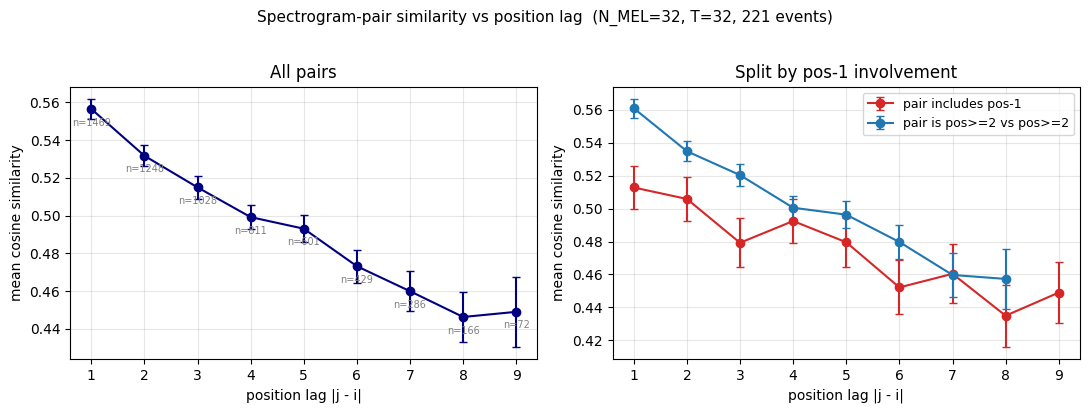

In [57]:
# Spectrogram-pair similarity vs position lag.
# Iterates over events in features_df with >= 3 calls, loads audio per call,
# computes log-mel spec, time-normalizes, and computes pairwise cosines.

import librosa
from scipy.ndimage import zoom
from vocalization_analysis.acoustic_features import load_call_slice

# ---- config ----
N_MEL    = 32       # mel bins
T_FRAMES = 32       # time-normalized frame count
PAD_SEC  = 0.01
MAX_POS_SPEC = 10   # cap calls per event to keep compute tractable
FMIN, FMAX = 1000, 60000

# Merge features_df with calls to get audio-loading coords.
needed_cols = ["bout_id", "bout_position", "exp", "channel", "file_num",
               "start_time_file_sec", "stop_time_file_sec"]
audio_lookup = calls[needed_cols].drop_duplicates(["bout_id", "bout_position"])
fd_audio = features_df.merge(audio_lookup, on=["bout_id", "bout_position"], how="left")
fd_audio = fd_audio.dropna(subset=needed_cols)
print(f"Calls with audio coords: {len(fd_audio):,}")

# Filter to events with >= 3 calls and positions <= MAX_POS_SPEC.
events_to_use = (
    fd_audio[fd_audio["event_position"] <= MAX_POS_SPEC]
    .groupby("event_id")
    .size()
)
events_to_use = events_to_use[events_to_use >= 3].index
print(f"Events with >= 3 calls (positions 1-{MAX_POS_SPEC}): {len(events_to_use)}")

fd_audio = fd_audio[fd_audio["event_id"].isin(events_to_use)].copy()

# ---- Compute log-mel spec per call, time-normalize, L2-normalize ----
def compute_normspec(y, sr):
    S = librosa.feature.melspectrogram(
        y=y.astype(np.float32), sr=sr,
        n_mels=N_MEL, n_fft=512, hop_length=256,
        fmin=FMIN, fmax=min(FMAX, sr // 2),
    )
    S_db = librosa.power_to_db(S + 1e-10, ref=np.max)  # (N_MEL, T)
    if S_db.shape[1] < 2:
        return None
    # Time-normalize to T_FRAMES using zoom on time axis.
    zoom_factor = T_FRAMES / S_db.shape[1]
    S_resized = zoom(S_db, zoom=(1.0, zoom_factor), order=1)
    # Trim/pad to exact T_FRAMES (zoom can be off by one).
    if S_resized.shape[1] > T_FRAMES:
        S_resized = S_resized[:, :T_FRAMES]
    elif S_resized.shape[1] < T_FRAMES:
        S_resized = np.pad(S_resized, ((0, 0),
                                       (0, T_FRAMES - S_resized.shape[1])),
                           mode="edge")
    v = S_resized.flatten()
    v = v - v.mean()
    n = np.linalg.norm(v)
    if n < 1e-8:
        return None
    return v / n

specs_by_call = {}  # (event_id, event_position) -> unit vector
failed = 0
for i, row in enumerate(fd_audio.itertuples(index=False)):
    try:
        y, sr = load_call_slice(
            BASE_PROCESSED_AUDIO,
            row.date_folder, row.exp, row.channel, row.file_num,
            row.start_time_file_sec, row.stop_time_file_sec,
            pad_sec=PAD_SEC,
        )
        v = compute_normspec(y, sr)
        if v is None:
            failed += 1
            continue
        specs_by_call[(row.event_id, row.event_position)] = v
    except Exception:
        failed += 1
    if (i + 1) % 500 == 0:
        print(f"  {i+1:,}/{len(fd_audio):,}")
print(f"Computed specs for {len(specs_by_call):,} calls ({failed} failed)")

# ---- Pairwise similarities within events ----
sim_records = []
for ev_id in events_to_use:
    calls_in_event = sorted(
        [(pos, specs_by_call.get((ev_id, pos)))
         for pos in range(1, MAX_POS_SPEC + 1)
         if (ev_id, pos) in specs_by_call],
        key=lambda t: t[0],
    )
    if len(calls_in_event) < 2:
        continue
    date = fd_audio.loc[fd_audio["event_id"] == ev_id, "date_folder"].iloc[0]
    for a in range(len(calls_in_event)):
        for b in range(a + 1, len(calls_in_event)):
            pos_a, v_a = calls_in_event[a]
            pos_b, v_b = calls_in_event[b]
            sim = float(np.dot(v_a, v_b))
            sim_records.append({
                "event_id": ev_id, "date_folder": date,
                "pos_a": pos_a, "pos_b": pos_b,
                "lag": abs(pos_b - pos_a),
                "involves_pos1": (pos_a == 1) or (pos_b == 1),
                "sim": sim,
            })

sim_df = pd.DataFrame(sim_records)
print(f"\nTotal pairs: {len(sim_df):,}")

# ---- Plot: mean similarity vs lag, two flavors ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: all pairs.
ax = axes[0]
agg_all = sim_df.groupby("lag")["sim"].agg(["mean", "sem", "count"])
ax.errorbar(agg_all.index, agg_all["mean"], yerr=agg_all["sem"],
            marker="o", color="navy", linewidth=1.5, capsize=3, label="all pairs")
ax.set_xlabel("position lag |j - i|")
ax.set_ylabel("mean cosine similarity")
ax.set_title("All pairs")
ax.set_xticks(range(1, MAX_POS_SPEC))
for lag, n in agg_all["count"].items():
    ax.annotate(f"n={int(n)}", (lag, agg_all.loc[lag, "mean"]),
                xytext=(0, -12), textcoords="offset points",
                ha="center", fontsize=7, color="gray")
ax.grid(alpha=0.3)

# Right: split by whether the pair involves position 1.
ax = axes[1]
for involves, color, label in [(True, "tab:red", "pair includes pos-1"),
                                (False, "tab:blue", "pair is pos>=2 vs pos>=2")]:
    sub = sim_df[sim_df["involves_pos1"] == involves]
    if sub.empty:
        continue
    agg = sub.groupby("lag")["sim"].agg(["mean", "sem", "count"])
    ax.errorbar(agg.index, agg["mean"], yerr=agg["sem"],
                marker="o", color=color, linewidth=1.5, capsize=3, label=label)
ax.set_xlabel("position lag |j - i|")
ax.set_ylabel("mean cosine similarity")
ax.set_title("Split by pos-1 involvement")
ax.set_xticks(range(1, MAX_POS_SPEC))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(
    f"Spectrogram-pair similarity vs position lag  "
    f"(N_MEL={N_MEL}, T={T_FRAMES}, {len(events_to_use)} events)",
    y=1.02, fontsize=11,
)
fig.tight_layout()
save_fig(fig, "alarm_spec_pair_similarity_vs_lag")
plt.show()

## Adjacent-pair similarity vs position

Complementary view to the similarity-vs-lag plot above:

- **Lag plot** = how *cumulative* drift grows with position-gap (averages over
  pairs anywhere in the event).
- **This plot** = similarity between *adjacent* calls, plotted by where in the
  event the pair sits. x = position of the later call; y = cosine similarity
  with the call at position x-1.

Reads:
- A **dip at x=2** quantifies the position-1 step (call 2 vs the distinct opener).
- A **flat profile from x=3 onward** means drift between adjacent calls is
  uniform (same shape change per step, regardless of where in the event).
- A **rising or falling profile** means drift speed varies through the event.

Adjacent pairs: 1,469
Events contributing: 221


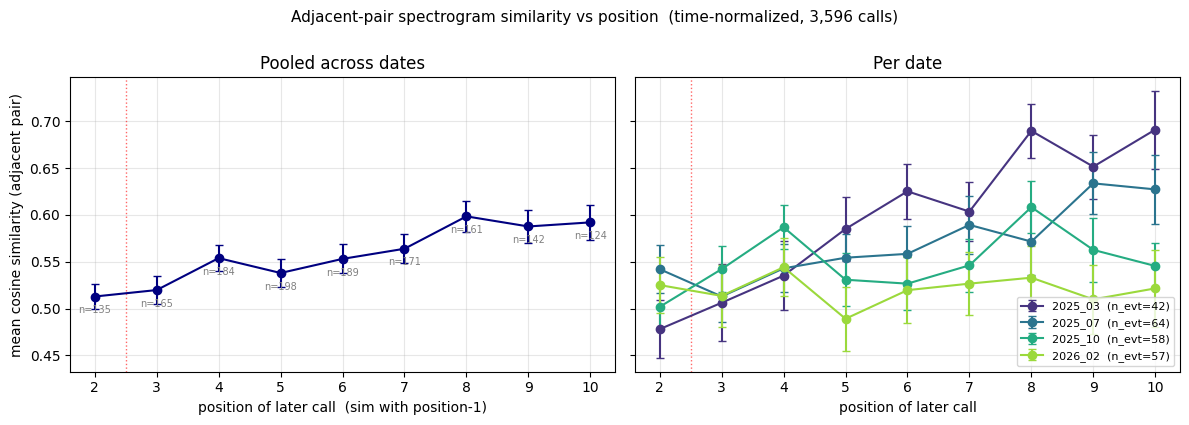

In [58]:
# Adjacent-pair similarity vs position-of-later-call.
# Uses the time-normalized specs (specs_by_call) - the version that worked for
# positions 2-15. Includes position 1 here, since the x=2 point is the whole
# point.

adj_records = []
events_set = set(ev for (ev, _) in specs_by_call.keys())

for ev_id in events_set:
    date = date_by_event.get(ev_id) if "date_by_event" in dir() else None
    if date is None:
        m = fd_audio.loc[fd_audio["event_id"] == ev_id, "date_folder"]
        if m.empty:
            continue
        date = m.iloc[0]
    for pos in range(2, MAX_POS_SPEC + 1):
        v_prev = specs_by_call.get((ev_id, pos - 1))
        v_curr = specs_by_call.get((ev_id, pos))
        if v_prev is None or v_curr is None:
            continue
        adj_records.append({
            "event_id":  ev_id,
            "date_folder": date,
            "position":  pos,           # position of the LATER call
            "sim":       float(np.dot(v_prev, v_curr)),
        })

adj_df = pd.DataFrame(adj_records)
print(f"Adjacent pairs: {len(adj_df):,}")
print(f"Events contributing: {adj_df['event_id'].nunique()}")

# ---- Plot: pooled + per-date ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

# Pooled (left).
ax = axes[0]
agg = adj_df.groupby("position")["sim"].agg(["mean", "sem", "count"])
ax.errorbar(agg.index, agg["mean"], yerr=agg["sem"],
            marker="o", color="navy", linewidth=1.5, capsize=3)
for pos, n in agg["count"].items():
    ax.annotate(f"n={int(n)}", (pos, agg.loc[pos, "mean"]),
                xytext=(0, -12), textcoords="offset points",
                ha="center", fontsize=7, color="gray")
ax.set_xlabel("position of later call  (sim with position-1)")
ax.set_ylabel("mean cosine similarity (adjacent pair)")
ax.set_title("Pooled across dates")
ax.set_xticks(range(2, MAX_POS_SPEC + 1))
ax.grid(alpha=0.3)
ax.axvline(2.5, color="red", linestyle=":", linewidth=1, alpha=0.6)

# Per-date (right).
ax = axes[1]
date_colors = {d: c for d, c in zip(
    DATES_TO_PLOT,
    plt.cm.viridis(np.linspace(0.15, 0.85, len(DATES_TO_PLOT)))
)}
for date in DATES_TO_PLOT:
    sub = adj_df[adj_df["date_folder"] == date]
    if sub.empty:
        continue
    agg = sub.groupby("position")["sim"].agg(["mean", "sem"])
    ax.errorbar(agg.index, agg["mean"], yerr=agg["sem"],
                marker="o", color=date_colors[date],
                linewidth=1.5, capsize=3,
                label=f"{date}  (n_evt={sub['event_id'].nunique()})")
ax.set_xlabel("position of later call")
ax.set_title("Per date")
ax.set_xticks(range(2, MAX_POS_SPEC + 1))
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
ax.axvline(2.5, color="red", linestyle=":", linewidth=1, alpha=0.6)

fig.suptitle(
    f"Adjacent-pair spectrogram similarity vs position  "
    f"(time-normalized, {len(specs_by_call):,} calls)",
    y=1.00, fontsize=11,
)
fig.tight_layout()
save_fig(fig, "alarm_spec_adjacent_similarity")
plt.show()

### Within-event slopes: is the stereotyping real, or selection bias?

For each event with at least 4 adjacent-call similarities (i.e., >=5 calls),
fit a simple linear regression `sim ~ position` and keep the slope. Distribution
of per-event slopes:

- **Median > 0, Wilcoxon p << 0.05** -> within events, adjacent calls reliably
  become more similar as the event progresses. Real signal.
- **Median ~ 0** -> the pooled rising curve was selection bias (longer events
  are more stereotyped on average, but no within-event tightening).

This is the artifact-vs-signal test.

Events with slope fit: 221
Median pairs per event: 10

Pooled: median slope = +0.00480,  Wilcoxon (slope > 0) p = 0.0001
  2025_03:  n= 42, median = +0.00799, Wilcoxon p (greater) = 0.0013
  2025_07:  n= 64, median = +0.00789, Wilcoxon p (greater) = 0.0037
  2025_10:  n= 58, median = +0.00405, Wilcoxon p (greater) = 0.073
  2026_02:  n= 57, median = +0.00086, Wilcoxon p (greater) = 0.34


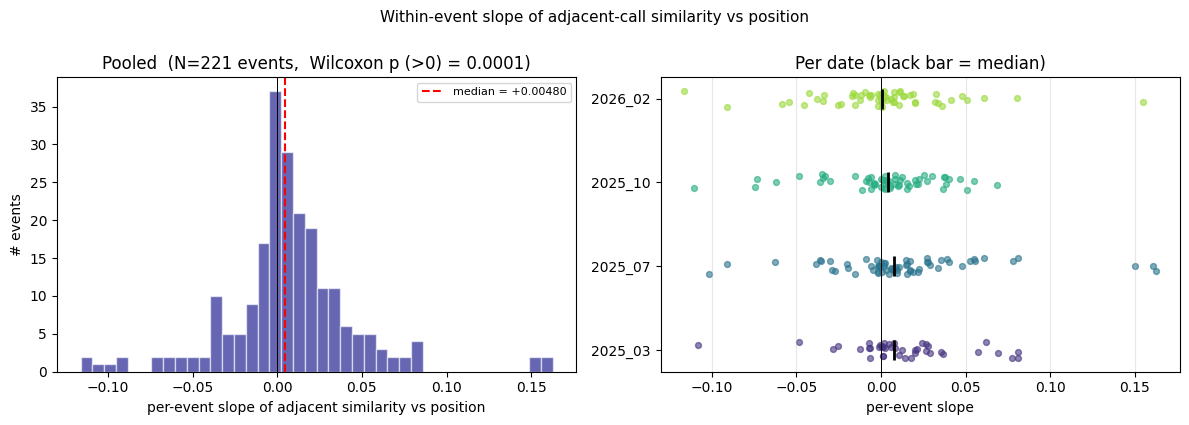

In [59]:
# Within-event slope: adjacent-call similarity ~ position, fit per event.

from scipy.stats import wilcoxon

# Build event -> {pos: vector} once.
event_calls = {}
for (ev_id, pos), v in specs_by_call.items():
    event_calls.setdefault(ev_id, {})[pos] = v

date_by_event = dict(zip(fd_audio["event_id"], fd_audio["date_folder"]))

slope_records = []
for ev_id, calls_here in event_calls.items():
    # Adjacent-pair similarities for this event.
    sims = []
    for p in sorted(calls_here):
        if (p - 1) in calls_here:
            sims.append((p, float(np.dot(calls_here[p - 1], calls_here[p]))))
    if len(sims) < 4:
        continue
    positions = np.array([p for p, _ in sims])
    sim_values = np.array([s for _, s in sims])
    slope, intercept = np.polyfit(positions, sim_values, 1)
    slope_records.append({
        "event_id":    ev_id,
        "date_folder": date_by_event.get(ev_id),
        "slope":       float(slope),
        "intercept":   float(intercept),
        "n_pairs":     len(sims),
    })

slopes_df = pd.DataFrame(slope_records)
slopes_df = slopes_df.dropna(subset=["date_folder", "slope"])
print(f"Events with slope fit: {len(slopes_df)}")
print(f"Median pairs per event: {slopes_df['n_pairs'].median():.0f}")

# Pooled and per-date Wilcoxon vs 0.
med_pool = slopes_df["slope"].median()
stat_pool, p_pool = wilcoxon(slopes_df["slope"], alternative="greater")
print(f"\nPooled: median slope = {med_pool:+.5f},  Wilcoxon (slope > 0) p = {p_pool:.2g}")
for date in DATES_TO_PLOT:
    s = slopes_df.loc[slopes_df["date_folder"] == date, "slope"]
    if len(s) < 3:
        continue
    med_d = s.median()
    stat_d, p_d = wilcoxon(s, alternative="greater")
    print(f"  {date}:  n={len(s):3d}, median = {med_d:+.5f}, "
          f"Wilcoxon p (greater) = {p_d:.2g}")

# ---- Plot: pooled histogram + per-date strip ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.hist(slopes_df["slope"], bins=40, color="navy", alpha=0.6, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.7)
ax.axvline(med_pool, color="red", linewidth=1.5, linestyle="--",
           label=f"median = {med_pool:+.5f}")
ax.set_xlabel("per-event slope of adjacent similarity vs position")
ax.set_ylabel("# events")
ax.set_title(
    f"Pooled  (N={len(slopes_df)} events,  Wilcoxon p (>0) = {p_pool:.2g})"
)
ax.legend(fontsize=8)

ax = axes[1]
date_colors = {d: c for d, c in zip(
    DATES_TO_PLOT,
    plt.cm.viridis(np.linspace(0.15, 0.85, len(DATES_TO_PLOT)))
)}
y_jitter = 0.10
for i, date in enumerate(DATES_TO_PLOT):
    s = slopes_df.loc[slopes_df["date_folder"] == date, "slope"]
    if s.empty:
        continue
    rng = np.random.default_rng(i)
    y_pos = i + rng.uniform(-y_jitter, y_jitter, size=len(s))
    ax.scatter(s, y_pos, color=date_colors[date], alpha=0.6, s=18)
    ax.scatter(s.median(), i, color="black", marker="|", s=200, linewidth=2)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_yticks(range(len(DATES_TO_PLOT)))
ax.set_yticklabels(DATES_TO_PLOT)
ax.set_xlabel("per-event slope")
ax.set_title("Per date (black bar = median)")
ax.grid(axis="x", alpha=0.3)

fig.suptitle("Within-event slope of adjacent-call similarity vs position",
             y=1.00, fontsize=11)
fig.tight_layout()
save_fig(fig, "alarm_spec_adjacent_slope_per_event")
plt.show()

### Distance-to-late-template: how close is each call to the "settled" shape?

Same idea as the LOO event-template plot, but the template is now defined as
the mean of **late-position calls only** (positions >= `LATE_THRESHOLD`,
default = 5). This is the cleanest test of "stereotypy at the end":

- **Late calls** (positions >= 5) are close to the template by construction
  (they define it). Leave-one-out so we don't double-count the call being
  scored.
- **Early calls** (positions 1-4) are *not* in the template - we ask how far
  each of them is from the settled-shape direction.

Expected pattern: rising line through the early positions, plateau at high
positions. Sharp drop only at position 1 = strong "opener" signal.

Calls with late-template sim: 3,521
Events contributing (have >= 2 calls at positions >= 5): 206


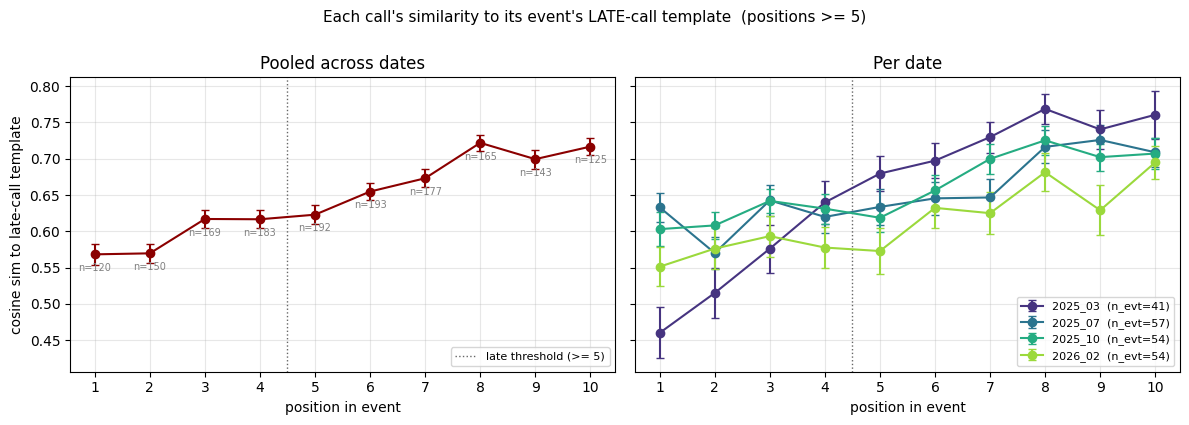

In [61]:
# Distance to late-call template, per call.

LATE_THRESHOLD = 5

late_tmpl_records = []
for ev_id, calls_here in event_calls.items():
    late_positions = [p for p in calls_here if p >= LATE_THRESHOLD]
    # Need at least 2 late calls so the LOO template still has >= 1 call.
    if len(late_positions) < 2:
        continue
    for p in sorted(calls_here):
        # LOO: drop the call being measured (only relevant if p itself is late).
        late_subset = [calls_here[q] for q in late_positions if q != p]
        if not late_subset:
            continue
        template = np.mean(late_subset, axis=0)
        n_t = np.linalg.norm(template)
        if n_t < 1e-8:
            continue
        sim = float(np.dot(calls_here[p], template) / n_t)
        late_tmpl_records.append({
            "event_id":      ev_id,
            "date_folder":   date_by_event.get(ev_id),
            "position":      p,
            "sim_to_late":   sim,
            "is_late_call":  p >= LATE_THRESHOLD,
        })

late_df = pd.DataFrame(late_tmpl_records)
print(f"Calls with late-template sim: {len(late_df):,}")
print(f"Events contributing (have >= 2 calls at positions >= {LATE_THRESHOLD}): "
      f"{late_df['event_id'].nunique()}")

# ---- Plot: pooled + per-date ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

ax = axes[0]
sub = late_df[late_df["position"] <= MAX_POS_SPEC]
agg = sub.groupby("position")["sim_to_late"].agg(["mean", "sem", "count"])
ax.errorbar(agg.index, agg["mean"], yerr=agg["sem"],
            marker="o", color="darkred", linewidth=1.5, capsize=3)
ax.axvline(LATE_THRESHOLD - 0.5, color="black", linestyle=":",
           linewidth=1, alpha=0.6,
           label=f"late threshold (>= {LATE_THRESHOLD})")
for pos, n in agg["count"].items():
    ax.annotate(f"n={int(n)}", (pos, agg.loc[pos, "mean"]),
                xytext=(0, -12), textcoords="offset points",
                ha="center", fontsize=7, color="gray")
ax.set_xlabel("position in event")
ax.set_ylabel("cosine sim to late-call template")
ax.set_title("Pooled across dates")
ax.set_xticks(range(1, MAX_POS_SPEC + 1))
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

ax = axes[1]
date_colors = {d: c for d, c in zip(
    DATES_TO_PLOT,
    plt.cm.viridis(np.linspace(0.15, 0.85, len(DATES_TO_PLOT)))
)}
for date in DATES_TO_PLOT:
    sub = late_df[(late_df["date_folder"] == date)
                  & (late_df["position"] <= MAX_POS_SPEC)]
    if sub.empty:
        continue
    agg = sub.groupby("position")["sim_to_late"].agg(["mean", "sem"])
    ax.errorbar(agg.index, agg["mean"], yerr=agg["sem"],
                marker="o", color=date_colors[date], linewidth=1.5, capsize=3,
                label=f"{date}  (n_evt={sub['event_id'].nunique()})")
ax.axvline(LATE_THRESHOLD - 0.5, color="black", linestyle=":",
           linewidth=1, alpha=0.6)
ax.set_xlabel("position in event")
ax.set_title("Per date")
ax.set_xticks(range(1, MAX_POS_SPEC + 1))
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

fig.suptitle(
    f"Each call's similarity to its event's LATE-call template  "
    f"(positions >= {LATE_THRESHOLD})",
    y=1.00, fontsize=11,
)
fig.tight_layout()
save_fig(fig, "alarm_spec_distance_to_late_template")
plt.show()

---

# Appendix: exploratory analyses and dead ends

Cells below either (a) showed that positions 2-15 do **not** carry decodable info in hand-engineered features (now superseded by the spectrogram analyses above), or (b) tested side hypotheses that did not lead anywhere (downstream prediction, opener-filtered subsets, PCA visualization, alternative model choices).

Kept for reference but not part of the main story.


## Decoder: predict time-since-event-onset from acoustic features

Different lens: if calls carry information about *where in the event they are*, a regression model on acoustic features should be able to predict each call's "time since the event started." We use:

- **Features**: `duration_s, peak_freq_hz, pitch_curvature_hz_per_call2, entropy_s, fm_median`. (`harmonic_density` isn't in our feature set — `entropy_s` is the closest proxy.)
- **Target**: time in seconds from the event's first call.
- **Model**: Ridge regression on standardized features.
- **CV**: `GroupKFold(5)` with **event_id** as the group — so train and test sets never share an event (no leakage from cumulative ICI structure).

We deliberately drop ICI from the feature set: time-since-onset is essentially a cumulative sum of ICIs, so including ICI would be near-circular.

Output: cross-validated R² and pearson r (how well does acoustic structure encode event-time?), plus standardized Ridge coefficients (which features carry the most weight, and in which direction).

In [ ]:
# Decoder: predict time_since_event_onset from acoustic features.
#
# Filter scope: we only care about the within-event trajectory in the
# first ~15 positions (~30 seconds). Outside that, events become
# pathologically long (thousands of calls, 1000+ seconds) and the
# regression collapses because acoustic features can't span such a
# wide y-axis.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

MAX_EVENT_POS_FOR_DECODER = 15
MAX_TIME_SINCE_ONSET_S    = 30.0     # cap to be safe, matches event-threshold scale

# --- Step 1: join absolute timing onto features_df if not already there. ---
if "start_time_real" not in features_df.columns:
    features_df = features_df.merge(
        calls[["bout_id", "bout_position", "start_time_real"]],
        on=["bout_id", "bout_position"], how="left",
    )

# --- Step 2: compute time_since_onset (seconds since the event's first call). ---
if "time_since_onset_s" not in features_df.columns:
    event_starts = (
        features_df.groupby("event_id", as_index=False)["start_time_real"].min()
        .rename(columns={"start_time_real": "_event_start"})
    )
    features_df = features_df.merge(event_starts, on="event_id", how="left")
    features_df["time_since_onset_s"] = (
        features_df["start_time_real"] - features_df["_event_start"]
    ).dt.total_seconds()
    features_df = features_df.drop(columns=["_event_start"])

# --- Step 3: feature matrix, target, groups, restricted to the analysis scope. ---
FEATURE_COLS = [
    "duration_s",
    "peak_freq_hz",
    "pitch_curvature_hz_per_call2",
    "entropy_s",
    "fm_median",
]
keep = features_df[
    (features_df["event_position"] <= MAX_EVENT_POS_FOR_DECODER)
    & (features_df["time_since_onset_s"] <= MAX_TIME_SINCE_ONSET_S)
][FEATURE_COLS + ["time_since_onset_s", "event_id", "event_position"]].dropna()
print(f"After filter to event_position <= {MAX_EVENT_POS_FOR_DECODER} "
      f"and time_since_onset <= {MAX_TIME_SINCE_ONSET_S}s: "
      f"{len(keep):,} calls across {keep['event_id'].nunique():,} events.")
print(f"time_since_onset range: {keep['time_since_onset_s'].min():.2f}s - "
      f"{keep['time_since_onset_s'].max():.2f}s")

X      = keep[FEATURE_COLS].values
y      = keep["time_since_onset_s"].values
groups = keep["event_id"].values

# --- Step 4: cross-validated Ridge, grouped by event_id. ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])
cv = GroupKFold(n_splits=5)
preds = cross_val_predict(pipe, X, y, cv=cv, groups=groups)

r2   = r2_score(y, preds)
r, _ = pearsonr(y, preds)
print(f"\nCross-validated  R² = {r2:.3f}   pearson r = {r:.3f}")

# --- Step 5: fit once on full data for interpretable coefficients. ---
pipe.fit(X, y)
coefs = pipe.named_steps["ridge"].coef_
print("\nStandardized Ridge coefficients (sign = direction of effect on time_since_onset):")
for col, c in sorted(zip(FEATURE_COLS, coefs), key=lambda p: -abs(p[1])):
    print(f"  {col:35s} {c:+.3f}")

# --- Step 6: plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                         gridspec_kw={"width_ratios": [1.4, 1.0]})

ax = axes[0]
sc = ax.scatter(
    y, preds, c=keep["event_position"].values,
    cmap="viridis", vmin=1, vmax=MAX_EVENT_POS_FOR_DECODER,
    s=10, alpha=0.45, edgecolor="none",
)
lo = min(y.min(), preds.min())
hi = max(y.max(), preds.max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, alpha=0.6, label="y = x")
ax.set_xlabel("Actual time since event onset (s)")
ax.set_ylabel("Predicted time since event onset (s)")
ax.set_title(f"Cross-validated predictions  (n = {len(keep):,} calls)\n"
             f"R² = {r2:.3f}   pearson r = {r:.3f}",
             loc="left", fontsize=10)
ax.legend(loc="upper left", fontsize=8)
plt.colorbar(sc, ax=ax, label="event_position", shrink=0.85)

ax = axes[1]
order = np.argsort(-np.abs(coefs))
sorted_cols  = [FEATURE_COLS[i] for i in order]
sorted_coefs = coefs[order]
bar_colors = ["#1f77b4" if c < 0 else "#d62728" for c in sorted_coefs]
ax.barh(range(len(sorted_coefs)), sorted_coefs, color=bar_colors)
ax.set_yticks(range(len(sorted_coefs)))
ax.set_yticklabels(sorted_cols, fontsize=9)
ax.axvline(0, color="black", linestyle="--", linewidth=0.6)
ax.set_xlabel("standardized Ridge coefficient")
ax.set_title("Feature importance\n(red = predicts LATER in event)",
             loc="left", fontsize=10)
ax.invert_yaxis()

fig.tight_layout()
save_fig(fig, "alarm_decoder_time_since_onset")
plt.show()

## Decoder: predict position-in-bout (or event) from acoustic features

Cleaner target than time-since-onset: position is integer-valued and doesn't carry ICI variance. Same five acoustic features, GroupKFold on the chosen scale's id.

Toggle `SCALE` between `"bout"` and `"event"` at the top of the cell to switch which grouping is used.

In [ ]:
# Decoder: predict position-in-bout (or in-event) from acoustic features.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

SCALE   = "bout"     # <-- toggle between "bout" and "event"
MAX_POS = 15         # cap to avoid the rare very-long-group outliers

id_col, pos_col, size_col = f"{SCALE}_id", f"{SCALE}_position", f"{SCALE}_size"

FEATURE_COLS = [
    "duration_s",
    "peak_freq_hz",
    "pitch_curvature_hz_per_call2",
    "entropy_s",
    "fm_median",
]

keep = features_df[
    features_df[pos_col] <= MAX_POS
][FEATURE_COLS + [pos_col, id_col]].dropna()

print(f"Using SCALE = {SCALE!r}, position <= {MAX_POS}.")
print(f"{len(keep):,} calls across {keep[id_col].nunique():,} {SCALE}s.")
print(f"position range: {keep[pos_col].min()} - {keep[pos_col].max()}")

X      = keep[FEATURE_COLS].values
y      = keep[pos_col].values.astype(float)
groups = keep[id_col].values

# Cross-validated Ridge, grouped by the chosen scale's id.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])
cv = GroupKFold(n_splits=5)
preds = cross_val_predict(pipe, X, y, cv=cv, groups=groups)

r2   = r2_score(y, preds)
r, _ = pearsonr(y, preds)
print(f"\nCross-validated  R² = {r2:.3f}   pearson r = {r:.3f}")

# Fit once on full data for interpretable coefficients.
pipe.fit(X, y)
coefs = pipe.named_steps["ridge"].coef_
print(f"\nStandardized Ridge coefficients (sign = direction of effect on {pos_col}):")
for col, c in sorted(zip(FEATURE_COLS, coefs), key=lambda p: -abs(p[1])):
    print(f"  {col:35s} {c:+.3f}")

# Plots.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                         gridspec_kw={"width_ratios": [1.4, 1.0]})

ax = axes[0]
# Add small jitter on x so integer positions don't pile on top of each other.
rng_jitter = np.random.default_rng(0)
y_jit = y + rng_jitter.uniform(-0.2, 0.2, size=len(y))
sc = ax.scatter(
    y_jit, preds, c=y, cmap="viridis", vmin=1, vmax=MAX_POS,
    s=10, alpha=0.45, edgecolor="none",
)
ax.plot([1, MAX_POS], [1, MAX_POS], "k--", linewidth=0.8, alpha=0.6, label="y = x")
ax.set_xlabel(f"Actual {pos_col} (jittered)")
ax.set_ylabel(f"Predicted {pos_col}")
ax.set_title(
    f"Cross-validated predictions  (n = {len(keep):,} calls, {SCALE} scale)\n"
    f"R² = {r2:.3f}   pearson r = {r:.3f}",
    loc="left", fontsize=10,
)
ax.legend(loc="upper left", fontsize=8)
plt.colorbar(sc, ax=ax, label=pos_col, shrink=0.85)

ax = axes[1]
order = np.argsort(-np.abs(coefs))
sorted_cols  = [FEATURE_COLS[i] for i in order]
sorted_coefs = coefs[order]
bar_colors = ["#1f77b4" if c < 0 else "#d62728" for c in sorted_coefs]
ax.barh(range(len(sorted_coefs)), sorted_coefs, color=bar_colors)
ax.set_yticks(range(len(sorted_coefs)))
ax.set_yticklabels(sorted_cols, fontsize=9)
ax.axvline(0, color="black", linestyle="--", linewidth=0.6)
ax.set_xlabel("standardized Ridge coefficient")
ax.set_title("Feature importance\n(red = predicts LATER position)",
             loc="left", fontsize=10)
ax.invert_yaxis()

fig.tight_layout()
save_fig(fig, f"alarm_decoder_position_{SCALE}")
plt.show()

## Is there position information beyond "first vs rest"?

Direct test: run the position decoder twice, side by side.
- **Run A**: positions 1-15 (full data, same as before).
- **Run B**: positions 2-15 only (position-1 calls removed).

If R² and pearson r in Run B are similar to Run A, there's gradient information across positions 2+ — calls carry more than just a binary first/not-first signal. If Run B crashes to ~0, the entire decodable signal was the first-call effect.


In [ ]:
# Position decoder on events: full data vs positions-2+ only.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

SCALE   = "event"
MAX_POS = 15

id_col, pos_col = f"{SCALE}_id", f"{SCALE}_position"

FEATURE_COLS = [
    "duration_s",
    "peak_freq_hz",
    "pitch_curvature_hz_per_call2",
    "entropy_s",
    "fm_median",
]

def run_position_decoder(min_pos, max_pos):
    keep = features_df[
        (features_df[pos_col] >= min_pos) & (features_df[pos_col] <= max_pos)
    ][FEATURE_COLS + [pos_col, id_col]].dropna()

    X      = keep[FEATURE_COLS].values
    y      = keep[pos_col].values.astype(float)
    groups = keep[id_col].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge",  Ridge(alpha=1.0)),
    ])
    preds = cross_val_predict(pipe, X, y, cv=GroupKFold(5), groups=groups)
    pipe.fit(X, y)

    return {
        "min_pos":   min_pos,
        "max_pos":   max_pos,
        "n_calls":   len(keep),
        "n_events":  keep[id_col].nunique(),
        "y":         y,
        "preds":     preds,
        "r2":        r2_score(y, preds),
        "pearson_r": pearsonr(y, preds)[0],
        "coefs":     pipe.named_steps["ridge"].coef_,
    }

res_full  = run_position_decoder(min_pos=1, max_pos=MAX_POS)
res_no1   = run_position_decoder(min_pos=2, max_pos=MAX_POS)

print(f"Run A: positions 1-{MAX_POS}  (full)")
print(f"  n_calls = {res_full['n_calls']:,}, n_events = {res_full['n_events']:,}")
print(f"  R² = {res_full['r2']:+.3f},  pearson r = {res_full['pearson_r']:+.3f}")
print()
print(f"Run B: positions 2-{MAX_POS}  (excludes first calls)")
print(f"  n_calls = {res_no1['n_calls']:,}, n_events = {res_no1['n_events']:,}")
print(f"  R² = {res_no1['r2']:+.3f},  pearson r = {res_no1['pearson_r']:+.3f}")
print()
print("Coefficient comparison (full vs pos-2+):")
print(f"  {'feature':35s}  {'full':>8s}  {'pos 2+':>8s}")
for col, c_full, c_no1 in zip(FEATURE_COLS, res_full["coefs"], res_no1["coefs"]):
    print(f"  {col:35s}  {c_full:+8.3f}  {c_no1:+8.3f}")

# Plot: predicted vs actual for both runs side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
rng_jitter = np.random.default_rng(0)

for ax, res, label in zip(axes, [res_full, res_no1],
                          [f"Positions 1-{MAX_POS} (full)",
                           f"Positions 2-{MAX_POS} (no first calls)"]):
    y = res["y"]
    y_jit = y + rng_jitter.uniform(-0.2, 0.2, size=len(y))
    sc = ax.scatter(
        y_jit, res["preds"], c=y, cmap="viridis",
        vmin=1, vmax=MAX_POS, s=8, alpha=0.4, edgecolor="none",
    )
    ax.plot([res["min_pos"], res["max_pos"]],
            [res["min_pos"], res["max_pos"]],
            "k--", linewidth=0.8, alpha=0.6, label="y = x")
    ax.set_xlabel(f"Actual {pos_col} (jittered)")
    if ax is axes[0]:
        ax.set_ylabel(f"Predicted {pos_col}")
    ax.set_title(
        f"{label}\nn = {res['n_calls']:,} calls,  "
        f"R² = {res['r2']:+.3f},  r = {res['pearson_r']:+.3f}",
        loc="left", fontsize=10,
    )
    ax.legend(loc="upper left", fontsize=8)

fig.colorbar(sc, ax=axes, label=pos_col, shrink=0.85)
fig.suptitle("Position decoder: full data vs positions-2+ only", y=1.02, fontsize=12)
save_fig(fig, "alarm_position_decoder_pos1_vs_pos2plus")
plt.show()


## Does the decoder do better with more / non-linear features?

Two ways to push the position-2+ decoder beyond the modest R² ≈ 0.04 from the 5-feature Ridge:

1. **All 24 features** — let Ridge see everything we extract, not just our hand-picked 5.
2. **Random Forest** (with all features) — captures non-linear relationships and feature interactions that a linear model can't.

If neither helps much, the limit is fundamental: per-call acoustic variance dominates the gradient signal.

If one or both clearly help, we have a better decoder and a story about which feature subset / model class is the right tool.


In [ ]:
# Decoder ablation: 5-feat Ridge vs 24-feat Ridge vs 24-feat RandomForest.
# All evaluated on positions 2-15 (the harder problem - no first-call effect).

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

SCALE   = "event"
MIN_POS = 2     # excludes first calls
MAX_POS = 15

id_col, pos_col = f"{SCALE}_id", f"{SCALE}_position"

# Subset 1: the original 5 features.
FEAT_5 = [
    "duration_s",
    "peak_freq_hz",
    "pitch_curvature_hz_per_call2",
    "entropy_s",
    "fm_median",
]

# Subset 2: all 24 features (the full FEATURE_COLUMNS we extract).
FEAT_ALL = list(FEATURE_COLUMNS)  # imported in setup cell

print(f"5-feature subset has  {len(FEAT_5)} features.")
print(f"All-feature subset has {len(FEAT_ALL)} features.")

def build_keep(feature_cols):
    return features_df[
        (features_df[pos_col] >= MIN_POS) & (features_df[pos_col] <= MAX_POS)
    ][feature_cols + [pos_col, id_col]].dropna()

def run(feature_cols, model, label):
    keep = build_keep(feature_cols)
    X      = keep[feature_cols].values
    y      = keep[pos_col].values.astype(float)
    groups = keep[id_col].values
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    preds = cross_val_predict(pipe, X, y, cv=GroupKFold(5), groups=groups)
    r2 = r2_score(y, preds)
    r, _ = pearsonr(y, preds)
    pipe.fit(X, y)
    print(f"  {label:42s}  R² = {r2:+.3f}   pearson r = {r:+.3f}   n = {len(keep):,}")
    return {
        "label": label, "r2": r2, "pearson_r": r, "pipe": pipe,
        "feature_cols": feature_cols,
    }

print(f"\n=== Predicting {pos_col} for positions {MIN_POS}-{MAX_POS} ===\n")
res_5_ridge   = run(FEAT_5,   Ridge(alpha=1.0),                                "5-feature  Ridge")
res_all_ridge = run(FEAT_ALL, Ridge(alpha=1.0),                                "all-feature Ridge")
res_all_rf    = run(FEAT_ALL, RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0),
                                                                                "all-feature RandomForest")

# Show top-10 feature importances for the all-feature models.
print("\n--- Top 10 features by |coef| (all-feature Ridge) ---")
ridge_coefs = res_all_ridge["pipe"].named_steps["model"].coef_
for col, c in sorted(zip(FEAT_ALL, ridge_coefs), key=lambda p: -abs(p[1]))[:10]:
    print(f"  {col:35s}  {c:+.3f}")

print("\n--- Top 10 features by importance (RandomForest) ---")
rf_imps = res_all_rf["pipe"].named_steps["model"].feature_importances_
for col, i in sorted(zip(FEAT_ALL, rf_imps), key=lambda p: -p[1])[:10]:
    print(f"  {col:35s}  {i:.3f}")

# Summary bar chart.
fig, ax = plt.subplots(figsize=(8, 3.2))
labels = [r["label"] for r in [res_5_ridge, res_all_ridge, res_all_rf]]
r2_vals = [r["r2"] for r in [res_5_ridge, res_all_ridge, res_all_rf]]
r_vals  = [r["pearson_r"] for r in [res_5_ridge, res_all_ridge, res_all_rf]]
xpos = np.arange(len(labels))
ax.barh(xpos - 0.18, r2_vals, height=0.36, color="#1f77b4", label="R²")
ax.barh(xpos + 0.18, r_vals,  height=0.36, color="#d62728", label="pearson r")
ax.set_yticks(xpos); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.axvline(0, color="black", linestyle="--", linewidth=0.5)
ax.set_xlabel("score (positions 2-15)")
ax.set_title("Decoder ablation: feature set + model class", loc="left", fontsize=10)
ax.legend(loc="lower right")
for i, (r2, r_) in enumerate(zip(r2_vals, r_vals)):
    ax.text(r2, i - 0.18, f" {r2:+.3f}", va="center", fontsize=8)
    ax.text(r_,  i + 0.18, f" {r_:+.3f}",  va="center", fontsize=8)
fig.tight_layout()
save_fig(fig, "alarm_decoder_ablation_pos2plus")
plt.show()


## Trajectories of the newly important features (from the ablation)

The 24-feat Ridge nearly doubled R² over the 5-feat Ridge on positions 2-15. The
top weights pointed to: `mean_s_hz`, `goodness_of_pitch_median`, `std_s_hz`,
`q2_hz`, `skew_s`. Plot their trajectories across event positions to *see* what's
continuously changing beyond the position-1 jump.

Same fan-chart pattern as before (median + IQR + 5-95%), but at the **event** scale.

In [ ]:
# Fan-chart trajectories for the features the ablation flagged as newly
# important (mean_s_hz, goodness_of_pitch_median, std_s_hz, q2_hz, skew_s).
# Same recipe as the earlier feature-trajectory cell, but at the EVENT scale.

NEW_FEATURES_TO_PLOT = [
    "mean_s_hz",                  # strongest single weight in 24-feat Ridge
    "goodness_of_pitch_median",   # YIN clarity - rises with position
    "std_s_hz",                   # spectral envelope width
    "q2_hz",                      # spectral median (50% energy quantile)
    "skew_s",                     # spectral envelope asymmetry
]
MAX_POS = 15

fig, axes = plt.subplots(
    len(NEW_FEATURES_TO_PLOT), len(DATES_TO_PLOT),
    figsize=(3.0 * len(DATES_TO_PLOT), 1.9 * len(NEW_FEATURES_TO_PLOT)),
    sharex=True,
    sharey="row",
)

for r, feat in enumerate(NEW_FEATURES_TO_PLOT):
    for c, date in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        sub = features_df[
            (features_df["date_folder"] == date)
            & (features_df["event_position"] <= MAX_POS)
        ]
        if sub.empty:
            ax.set_axis_off()
            continue

        mat = sub.pivot_table(
            index="event_id", columns="event_position", values=feat, aggfunc="mean",
        )
        if mat.empty or mat.notna().sum().sum() == 0:
            ax.set_axis_off()
            continue

        p05    = mat.quantile(0.05, axis=0)
        p25    = mat.quantile(0.25, axis=0)
        median = mat.median(axis=0)
        p75    = mat.quantile(0.75, axis=0)
        p95    = mat.quantile(0.95, axis=0)

        ax.fill_between(median.index, p05, p95, color="steelblue", alpha=0.10)
        ax.fill_between(median.index, p25, p75, color="steelblue", alpha=0.25)
        ax.plot(median.index, median.values, "-o", color="navy",
                linewidth=1.5, markersize=3)

        if r == 0:
            ax.set_title(date, fontsize=10)
        if c == 0:
            ax.set_ylabel(feat, fontsize=9)

for ax in axes[-1]:
    ax.set_xticks(range(1, MAX_POS + 1, 2))
    ax.set_xlabel("position in event")

fig.suptitle(
    "Within-event trajectories of newly important features  "
    "(median, IQR, 5-95%)"
)
fig.tight_layout()
save_fig(fig, "alarm_new_feature_trajectories_event")
plt.show()

## Best-case test: does the 2-15 trajectory exist in events with a distinguishable first call?

Filter to events where call-1 is clearly different from the rest, then run the
position 2-15 decoder *only* on that subset. If the gradient signal beyond
position 1 exists at all, this is where it should show up most cleanly.

- **Salience score** per event = Euclidean distance, in standardized 5-feature
  space, between call-1 and the median of calls 2-N. Units = SDs.
- Pick a threshold from the distribution plot below.

In [ ]:
# Best-case test: filter events by "first-call salience", then run the 24-feat
# Ridge on positions 2-15 within the filtered subset only.

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# ---- config ----
SALIENCE_FEATURES = [
    "duration_s",
    "pitch_curvature_hz_per_call2",
    "fm_median",
    "fm_early",
    "fm_late",
]
MAX_POS = 15
THRESHOLD = None  # if None, use top-quartile (75th percentile)

# All 24 features for the decoder (the columns added by compute_features).
DECODER_FEATURES = [c for c in FEATURE_COLUMNS if c in features_df.columns]

# ---- 1. Compute per-event salience score ----
# Standardize the salience features across all calls in features_df.
sal_data = features_df[SALIENCE_FEATURES].copy()
sal_z = (sal_data - sal_data.mean()) / sal_data.std()
sal_z["event_id"] = features_df["event_id"].values
sal_z["event_position"] = features_df["event_position"].values

salience_records = []
for ev_id, ev in sal_z.groupby("event_id"):
    if ev["event_position"].min() != 1 or len(ev) < 3:
        continue
    first = ev.loc[ev["event_position"] == 1, SALIENCE_FEATURES].mean()
    rest_median = ev.loc[ev["event_position"] >= 2, SALIENCE_FEATURES].median()
    if first.isna().any() or rest_median.isna().any():
        continue
    score = float(np.linalg.norm(first.values - rest_median.values))
    salience_records.append({"event_id": ev_id, "salience": score, "n_calls": len(ev)})

salience_df = pd.DataFrame(salience_records)
print(f"Events with salience score: {len(salience_df)}")
print(f"\nPercentiles of salience score:")
for p in (25, 50, 75, 90, 95):
    print(f"  {p}th : {np.percentile(salience_df['salience'], p):.2f}")

if THRESHOLD is None:
    THRESHOLD = float(np.percentile(salience_df["salience"], 75))
    print(f"\nUsing default THRESHOLD = 75th percentile = {THRESHOLD:.2f}")
else:
    print(f"\nUsing THRESHOLD = {THRESHOLD:.2f}")

# ---- 2. Plot the salience distribution ----
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(salience_df["salience"], bins=40, color="steelblue", alpha=0.7,
        edgecolor="white")
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"threshold = {THRESHOLD:.2f}")
ax.set_xlabel("first-call salience score (SDs in 5-feature space)")
ax.set_ylabel("# events")
ax.set_title("Distribution of first-call salience across events")
ax.legend()
fig.tight_layout()
plt.show()

# ---- 3. Filter features_df to events above threshold ----
selected_events = set(salience_df.loc[salience_df["salience"] >= THRESHOLD, "event_id"])
sub = features_df[
    (features_df["event_id"].isin(selected_events))
    & (features_df["event_position"] >= 2)
    & (features_df["event_position"] <= MAX_POS)
].copy()
sub = sub.dropna(subset=DECODER_FEATURES + ["event_position", "event_id"])

print(f"\nFiltered subset: {len(selected_events)} events, "
      f"{sub['event_id'].nunique()} events with positions 2-{MAX_POS}, "
      f"{len(sub)} calls.")

# ---- 4. Run 24-feat Ridge on positions 2-15 in the filtered subset ----
X = sub[DECODER_FEATURES].values
y = sub["event_position"].values
groups = sub["event_id"].values

n_groups = sub["event_id"].nunique()
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)
pipe = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=1.0))])

y_pred = cross_val_predict(pipe, X, y, groups=groups, cv=gkf)
r2 = r2_score(y, y_pred)
r, _ = pearsonr(y, y_pred)

print(f"\n24-feat Ridge, positions 2-{MAX_POS}, salience >= {THRESHOLD:.2f}:")
print(f"  R^2 = {r2:.3f}")
print(f"  r   = {r:.3f}")
print(f"\nBaseline (no filter, full set): R^2 = 0.069, r = 0.27")

# ---- 5. Quick scatter of true vs predicted ----
fig, ax = plt.subplots(figsize=(4.5, 4.2))
ax.scatter(y + np.random.uniform(-0.2, 0.2, size=len(y)), y_pred,
           alpha=0.25, s=12, color="navy")
ax.plot([2, MAX_POS], [2, MAX_POS], "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("true event_position")
ax.set_ylabel("predicted event_position")
ax.set_title(f"Filtered decoder  (R^2={r2:.3f}, r={r:.2f})")
ax.set_xticks(range(2, MAX_POS + 1, 2))
fig.tight_layout()
plt.show()

## Does first-call salience predict anything downstream?

Test whether events with a more acoustically-distinguishable first call (high
salience score, computed above) differ in:

1. **Event size** — does a strong opener predict more calls in the event?
2. **Event duration (s)** — same, in time units.
3. **Gap to next event (s)** — does a strong opener predict longer silence after?

And one **upstream control**:

4. **Gap from previous event (s)** — needed to rule out reverse causation
   (maybe the opener looks "different" simply because there's been a long
   silence and the next call is acoustically reset by that).

For each: scatter colored by date + pooled Spearman correlation.

In [ ]:
# Does first-call salience predict downstream event properties?
# Uses salience_df (computed in the previous cell) and events_meta.

from scipy.stats import spearmanr

# --- 1. Build per-event downstream table ---
# events_meta columns we use: event_size, duration_s, gap_s (gap from prev),
# start_time, stop_time, date_folder. duration_s is already computed by
# summarize_scale.
ev_outcomes = (
    events_meta.copy()
    .sort_values(["date_folder", "start_time"])
    .reset_index()  # event_id was the index
)

# Gap from previous event (already computed as gap_s by summarize_scale).
ev_outcomes["gap_from_prev_s"] = ev_outcomes["gap_s"]

# Gap to next event: shift gap_s by -1 within date (next event's gap_from_prev
# is this event's gap_to_next).
ev_outcomes["gap_to_next_s"] = (
    ev_outcomes.groupby("date_folder")["gap_s"].shift(-1)
)

# Merge with salience.
merged = salience_df.merge(
    ev_outcomes[["event_id", "event_size", "duration_s", "gap_to_next_s",
                 "gap_from_prev_s", "date_folder"]],
    on="event_id",
    how="left",
)

print(f"Events with salience + downstream measures: {len(merged)}")
print(f"  with gap_to_next_s defined:   {merged['gap_to_next_s'].notna().sum()}")
print(f"  with gap_from_prev_s defined: {merged['gap_from_prev_s'].notna().sum()}")

# --- 2. Plot scatter + Spearman per downstream measure ---
MEASURES = [
    ("event_size",       "Event size (# calls)",         False),
    ("duration_s",       "Event duration (s)",            True),  # log-y
    ("gap_to_next_s",    "Gap to next event (s)",         True),  # log-y
    ("gap_from_prev_s",  "Gap from previous event (s)  [control]", True),  # log-y
]

date_colors = {d: c for d, c in zip(
    DATES_TO_PLOT,
    plt.cm.viridis(np.linspace(0.15, 0.85, len(DATES_TO_PLOT)))
)}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, (col, label, log_y) in zip(axes, MEASURES):
    sub = merged.dropna(subset=["salience", col])
    if log_y:
        sub = sub[sub[col] > 0]

    for date in DATES_TO_PLOT:
        d_sub = sub[sub["date_folder"] == date]
        if d_sub.empty:
            continue
        ax.scatter(
            d_sub["salience"], d_sub[col],
            color=date_colors[date], alpha=0.55, s=22,
            label=date,
        )

    # Pooled Spearman across all dates.
    if len(sub) >= 5:
        rho, pval = spearmanr(sub["salience"], sub[col])
        title = f"{label}\nSpearman rho={rho:+.2f}, p={pval:.2g},  N={len(sub)}"
    else:
        title = f"{label}\nN={len(sub)} (too few)"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("first-call salience (SDs)")
    ax.set_ylabel(label.split("\n")[0])
    if log_y:
        ax.set_yscale("log")
    ax.legend(fontsize=8, loc="best")

fig.suptitle(
    "Does first-call salience predict downstream event properties?",
    fontsize=12, y=1.00,
)
fig.tight_layout()
save_fig(fig, "alarm_salience_vs_downstream")
plt.show()

### Same test, but with a 1-D duration-based opener score

Same downstream measures, but x-axis is now:

`opener_score_s = call_1.duration_s - median(duration_s of calls 2-N)`

Cleaner than multi-feature salience: duration was the strongest single feature
in the first-vs-rest paired test, it's interpretable, and the 1-D version isn't
inflated by median-noise in small events the way the 5-D distance was.

Events with opener_score: 135
opener_score_s percentiles: 5%=-0.048, 50%=+0.033, 95%=+0.158


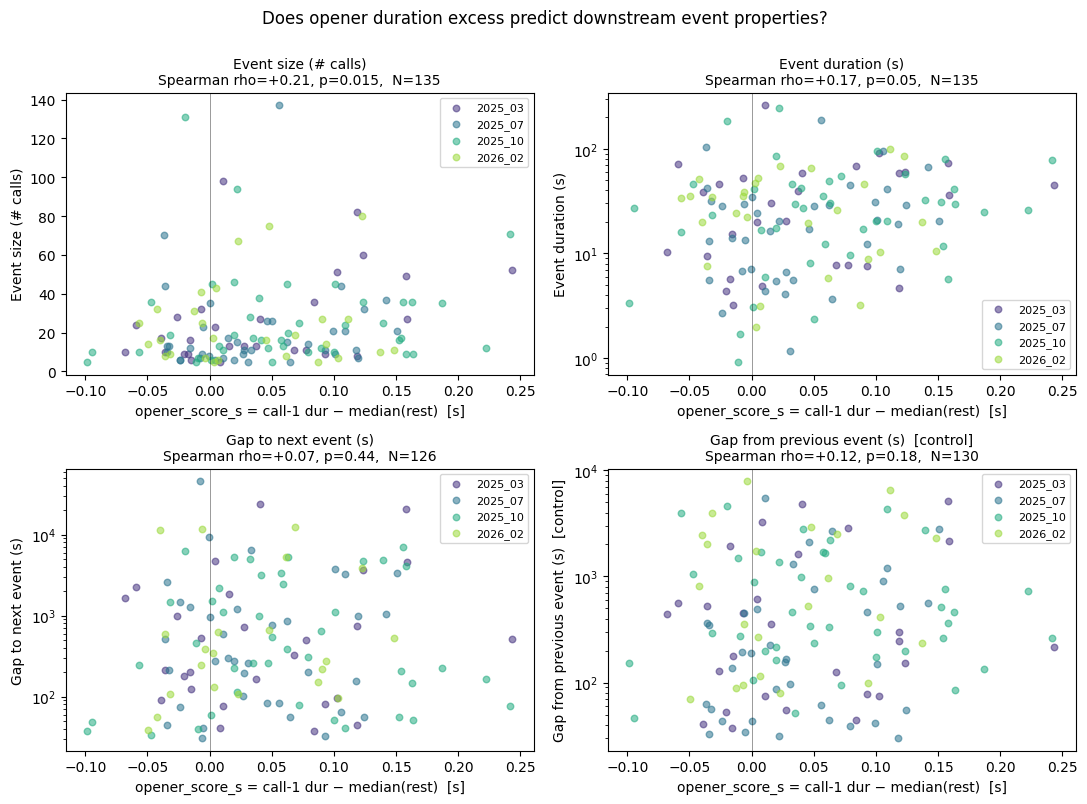

In [42]:
# Same downstream test, but x-axis = call-1 duration minus median(rest) in seconds.

from scipy.stats import spearmanr

# --- 1. Build opener_score_s per event from features_df ---
opener_records = []
for ev_id, ev in features_df.groupby("event_id"):
    if ev["event_position"].min() != 1 or len(ev) < 3:
        continue
    first_dur = ev.loc[ev["event_position"] == 1, "duration_s"]
    rest_dur  = ev.loc[ev["event_position"] >= 2, "duration_s"]
    if first_dur.empty or rest_dur.empty:
        continue
    opener_records.append({
        "event_id": ev_id,
        "opener_score_s": float(first_dur.mean() - rest_dur.median()),
        "first_dur_s":    float(first_dur.mean()),
    })

opener_df = pd.DataFrame(opener_records)
print(f"Events with opener_score: {len(opener_df)}")
print(f"opener_score_s percentiles: "
      f"5%={np.percentile(opener_df['opener_score_s'], 5):+.3f}, "
      f"50%={np.percentile(opener_df['opener_score_s'], 50):+.3f}, "
      f"95%={np.percentile(opener_df['opener_score_s'], 95):+.3f}")

# --- 2. Merge with downstream measures ---
merged = opener_df.merge(
    ev_outcomes[["event_id", "event_size", "duration_s", "gap_to_next_s",
                 "gap_from_prev_s", "date_folder"]],
    on="event_id",
    how="left",
).rename(columns={"duration_s": "event_duration_s"})

# --- 3. Plot ---
MEASURES = [
    ("event_size",       "Event size (# calls)",                  False),
    ("event_duration_s", "Event duration (s)",                     True),
    ("gap_to_next_s",    "Gap to next event (s)",                  True),
    ("gap_from_prev_s",  "Gap from previous event (s)  [control]", True),
]

date_colors = {d: c for d, c in zip(
    DATES_TO_PLOT,
    plt.cm.viridis(np.linspace(0.15, 0.85, len(DATES_TO_PLOT)))
)}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, (col, label, log_y) in zip(axes, MEASURES):
    sub = merged.dropna(subset=["opener_score_s", col])
    if log_y:
        sub = sub[sub[col] > 0]

    for date in DATES_TO_PLOT:
        d_sub = sub[sub["date_folder"] == date]
        if d_sub.empty:
            continue
        ax.scatter(
            d_sub["opener_score_s"], d_sub[col],
            color=date_colors[date], alpha=0.55, s=22,
            label=date,
        )

    if len(sub) >= 5:
        rho, pval = spearmanr(sub["opener_score_s"], sub[col])
        title = f"{label}\nSpearman rho={rho:+.2f}, p={pval:.2g},  N={len(sub)}"
    else:
        title = f"{label}\nN={len(sub)} (too few)"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("opener_score_s = call-1 dur − median(rest)  [s]")
    ax.axvline(0, color="black", linewidth=0.7, alpha=0.4)
    ax.set_ylabel(label.split("\n")[0])
    if log_y:
        ax.set_yscale("log")
    ax.legend(fontsize=8, loc="best")

fig.suptitle(
    "Does opener duration excess predict downstream event properties?",
    fontsize=12, y=1.00,
)
fig.tight_layout()
save_fig(fig, "alarm_opener_dur_vs_downstream")
plt.show()

## Multi-feature-pair scatter: which 2D view separates positions?

Same recipe as the duration-vs-curvature scatter (per-event lines + per-position
medians, colored by position), stacked as three rows for three feature pairs:

1. **duration × pitch_curvature** — the original.
2. **fm_early × fm_late** — tests the within-call temporal shift hypothesis
   (FM action sliding from early to late in the call across positions).
3. **mean_s × goodness_of_pitch** — top two features from the decoder ablation.

Look at the per-position median trajectory (filled markers connected by black
line) in each panel: does it sweep through 2D in a position-ordered way, or
collapse to a blob with position 1 offset?

In [ ]:
# 3-row scatter grid: three feature pairs (rows) x 4 dates (cols).
# Same recipe as the duration-vs-curvature cell above.

SCALE = "event"
id_col, pos_col, size_col = f"{SCALE}_id", f"{SCALE}_position", f"{SCALE}_size"

PAIRS = [
    # (x_col, y_col, x_label, y_label, x_cap, y_cap)
    ("duration_s", "pitch_curvature_hz_per_call2",
     "duration (ms)", "pitch_curvature_hz_per_call2",
     250.0, None),    # x in ms, no y cap
    ("fm_early", "fm_late",
     "fm_early (rad)", "fm_late (rad)",
     None, None),
    ("mean_s_hz", "goodness_of_pitch_median",
     "mean_s_hz", "goodness_of_pitch_median",
     None, None),
]

MAX_POS_SCATTER = 15
N_GROUP_LINES   = 40
LINE_SEED       = 1

cmap = plt.get_cmap("viridis")
rng_line = np.random.default_rng(LINE_SEED)

fig, axes = plt.subplots(
    len(PAIRS), len(DATES_TO_PLOT),
    figsize=(3.6 * len(DATES_TO_PLOT), 3.6 * len(PAIRS)),
)

for r, (x_col, y_col, x_label, y_label, x_cap, y_cap) in enumerate(PAIRS):
    for c, date in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        sub = features_df[
            (features_df["date_folder"] == date)
            & (features_df[pos_col] <= MAX_POS_SCATTER)
            & features_df[x_col].notna()
            & features_df[y_col].notna()
        ].copy()
        if x_col == "duration_s":
            sub["x_plot"] = sub[x_col] * 1000  # to ms
        else:
            sub["x_plot"] = sub[x_col]
        sub["y_plot"] = sub[y_col]
        if x_cap is not None:
            sub = sub[sub["x_plot"] <= x_cap]
        if y_cap is not None:
            sub = sub[sub["y_plot"] <= y_cap]
        if sub.empty:
            ax.set_axis_off()
            continue

        # Layer 1: thin per-group lines.
        group_ids = sub[id_col].unique()
        n_pick = min(N_GROUP_LINES, len(group_ids))
        picked = rng_line.choice(group_ids, size=n_pick, replace=False)
        for gid in picked:
            gdata = sub[sub[id_col] == gid].sort_values(pos_col)
            if len(gdata) < 2:
                continue
            ax.plot(gdata["x_plot"], gdata["y_plot"],
                    "-", color="gray", linewidth=0.4, alpha=0.25, zorder=2)

        # Layer 2: scatter cloud.
        sc = ax.scatter(
            sub["x_plot"], sub["y_plot"],
            c=sub[pos_col], cmap=cmap, vmin=1, vmax=MAX_POS_SCATTER,
            s=8, alpha=0.45, edgecolor="none", zorder=4,
        )

        # Layer 3: per-position medians.
        medians = []
        for pos in range(1, MAX_POS_SCATTER + 1):
            ps = sub[sub[pos_col] == pos]
            if len(ps) < 5:
                continue
            medians.append({
                "position": pos,
                "x": ps["x_plot"].median(),
                "y": ps["y_plot"].median(),
            })
        med_df = pd.DataFrame(medians)
        if not med_df.empty:
            ax.plot(med_df["x"], med_df["y"], "-",
                    color="black", linewidth=1.5, alpha=0.85, zorder=9)
            ax.scatter(
                med_df["x"], med_df["y"],
                c=med_df["position"], cmap=cmap, vmin=1, vmax=MAX_POS_SCATTER,
                s=90, edgecolor="black", linewidth=0.8, zorder=10,
            )

        if r == 0:
            ax.set_title(f"{date}  (n={len(sub):,} calls, {n_pick} {SCALE} lines)",
                         fontsize=9, loc="left")
        if r == len(PAIRS) - 1:
            ax.set_xlabel(x_label)
        if c == 0:
            ax.set_ylabel(y_label)

cbar = fig.colorbar(sc, ax=axes, label=f"position in {SCALE}", pad=0.02, shrink=0.7)
cbar.set_ticks(range(1, MAX_POS_SCATTER + 1, 2))

fig.suptitle("Multi-feature-pair scatter: per-event lines + per-position medians",
             y=1.00, fontsize=12)
fig.tight_layout()
save_fig(fig, f"alarm_multipair_scatter_per_{SCALE}")
plt.show()

## (2) PCA on spectrograms, colored by position

Take the time-normalized log-mel spectrograms we just built (`specs_by_call`),
fit PCA across **all calls pooled** (so the axes are consistent across dates),
and project to 2D.

In each per-date panel: scatter of every call colored by position + per-position
median trajectory (black line through filled markers). If position 1 sits in a
corner of PCA space and 2-15 sweep through 2D in a position-ordered way, we
have continuous drift visible in the principal axes.

In [ ]:
# PCA on spectrograms, pooled across dates so PCs are shared.
# Reuses specs_by_call from the spectrogram-similarity cell.

from sklearn.decomposition import PCA

# ---- 1. Stack all spectrograms into a matrix + collect metadata ----
date_by_event = dict(zip(fd_audio["event_id"], fd_audio["date_folder"]))

records = []
vectors = []
for (ev_id, pos), v in specs_by_call.items():
    if pos > MAX_POS_SPEC:
        continue
    date = date_by_event.get(ev_id)
    if date is None:
        continue
    records.append({"event_id": ev_id, "event_position": pos, "date_folder": date})
    vectors.append(v)

X = np.vstack(vectors)
meta = pd.DataFrame(records)
print(f"PCA input: {X.shape[0]} calls x {X.shape[1]} pixels")

# ---- 2. Fit PCA (pooled) ----
pca = PCA(n_components=10)
Z = pca.fit_transform(X)
print(f"\nExplained variance ratio (first 5 PCs):")
for k in range(5):
    print(f"  PC{k+1}: {pca.explained_variance_ratio_[k]:.3f}")
print(f"  cum. PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.3f}")

meta["PC1"] = Z[:, 0]
meta["PC2"] = Z[:, 1]

# ---- 3. Scatter per date with per-position median trajectory ----
MAX_POS_PCA = MAX_POS_SPEC
cmap = plt.get_cmap("viridis")

# Shared limits across panels (so per-position trajectories are comparable).
xlim = (np.percentile(meta["PC1"], 0.5), np.percentile(meta["PC1"], 99.5))
ylim = (np.percentile(meta["PC2"], 0.5), np.percentile(meta["PC2"], 99.5))

fig, axes = plt.subplots(1, len(DATES_TO_PLOT),
                         figsize=(4.0 * len(DATES_TO_PLOT), 4.2),
                         sharex=True, sharey=True)

for ax, date in zip(axes, DATES_TO_PLOT):
    sub = meta[meta["date_folder"] == date]
    if sub.empty:
        ax.set_axis_off()
        continue

    sc = ax.scatter(
        sub["PC1"], sub["PC2"],
        c=sub["event_position"],
        cmap=cmap, vmin=1, vmax=MAX_POS_PCA,
        s=12, alpha=0.45, edgecolor="none", zorder=3,
    )

    # Per-position medians + connecting line.
    medians = []
    for pos in range(1, MAX_POS_PCA + 1):
        ps = sub[sub["event_position"] == pos]
        if len(ps) < 5:
            continue
        medians.append({"position": pos,
                        "PC1": ps["PC1"].median(),
                        "PC2": ps["PC2"].median()})
    med_df = pd.DataFrame(medians)
    if not med_df.empty:
        ax.plot(med_df["PC1"], med_df["PC2"], "-",
                color="black", linewidth=1.5, alpha=0.85, zorder=9)
        ax.scatter(med_df["PC1"], med_df["PC2"],
                   c=med_df["position"], cmap=cmap,
                   vmin=1, vmax=MAX_POS_PCA,
                   s=110, edgecolor="black", linewidth=0.9, zorder=10)

    ax.set_title(f"{date}  (n={len(sub):,})", fontsize=10)
    ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

axes[0].set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")

cbar = fig.colorbar(sc, ax=axes, label="position in event",
                    pad=0.02, shrink=0.85)
cbar.set_ticks(range(1, MAX_POS_PCA + 1, 2))

fig.suptitle("Spectrogram PCA  ·  scatter + per-position median trajectory",
             y=1.02, fontsize=11)
save_fig(fig, "alarm_spec_pca_per_date")
plt.show()

## Best-case redo: spectrogram analyses on events with a clearly longer opener

Same logic as the salience-filtered decoder test above, but now applied to the
spectrogram-based analyses (which actually had drift signal in the unrestricted
test). Filter to events with `opener_score_s = call_1.duration_s − median(rest)`
above a threshold, then re-run:

1. Similarity-vs-lag per date (this cell).
2. Spectrogram decoder on positions 2-15 (next cell).

If the drift was *amplified* by the long-opener events, both should look
sharper than the unrestricted versions. If they look the same or weaker, the
position-1 distinctness and the within-event shape drift are independent
phenomena.

In [ ]:
# Filter events by opener_score_s and re-run spectrogram-pair similarity.
# Reuses opener_df, specs_by_call, fd_audio from earlier cells.

# ---- config ----
THRESHOLD_S = 0.05   # call-1 must be at least 50 ms longer than median(rest)

# Show threshold on opener_score distribution.
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(opener_df["opener_score_s"], bins=40, color="steelblue", alpha=0.7,
        edgecolor="white")
ax.axvline(THRESHOLD_S, color="red", linestyle="--", linewidth=1.5,
           label=f"threshold = {THRESHOLD_S:+.2f} s")
ax.axvline(0, color="black", linewidth=0.7, alpha=0.4)
ax.set_xlabel("opener_score_s = call-1 dur - median(rest) [s]")
ax.set_ylabel("# events")
ax.set_title("Opener-duration excess: where the threshold sits")
ax.legend()
fig.tight_layout()
plt.show()

selected_events = set(opener_df.loc[opener_df["opener_score_s"] >= THRESHOLD_S, "event_id"])
print(f"\nSelected {len(selected_events)} / {len(opener_df)} events "
      f"(opener_score_s >= {THRESHOLD_S:+.2f} s).")
print(f"Selected events by date:")
print(opener_df[opener_df["event_id"].isin(selected_events)]
      .merge(fd_audio[["event_id", "date_folder"]].drop_duplicates(), on="event_id")
      .groupby("date_folder").size().to_string())

# ---- Re-compute pairwise similarities on the selected events only ----
date_by_event = dict(zip(fd_audio["event_id"], fd_audio["date_folder"]))

sub_sim_records = []
for ev_id in selected_events:
    calls_in_event = sorted(
        [(pos, specs_by_call.get((ev_id, pos)))
         for pos in range(1, MAX_POS_SPEC + 1)
         if (ev_id, pos) in specs_by_call],
        key=lambda t: t[0],
    )
    if len(calls_in_event) < 2:
        continue
    date = date_by_event.get(ev_id)
    if date is None:
        continue
    for a in range(len(calls_in_event)):
        for b in range(a + 1, len(calls_in_event)):
            pos_a, v_a = calls_in_event[a]
            pos_b, v_b = calls_in_event[b]
            sim = float(np.dot(v_a, v_b))
            sub_sim_records.append({
                "event_id": ev_id, "date_folder": date,
                "pos_a": pos_a, "pos_b": pos_b,
                "lag": abs(pos_b - pos_a),
                "involves_pos1": (pos_a == 1) or (pos_b == 1),
                "sim": sim,
            })

sub_sim_df = pd.DataFrame(sub_sim_records)
print(f"\nFiltered subset pairs: {len(sub_sim_df):,}")

# ---- Plot: per-date, two panels (all pairs, pos>=2 only) ----
date_colors = {d: c for d, c in zip(
    DATES_TO_PLOT,
    plt.cm.viridis(np.linspace(0.15, 0.85, len(DATES_TO_PLOT)))
)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, sub_df, title in [
    (axes[0], sub_sim_df,                                  "All pairs"),
    (axes[1], sub_sim_df[~sub_sim_df["involves_pos1"]],    "pos>=2 vs pos>=2 only"),
]:
    for date in DATES_TO_PLOT:
        d_sub = sub_df[sub_df["date_folder"] == date]
        if d_sub.empty:
            continue
        agg = d_sub.groupby("lag")["sim"].agg(["mean", "sem", "count"])
        ax.errorbar(
            agg.index, agg["mean"], yerr=agg["sem"],
            marker="o", color=date_colors[date], linewidth=1.5,
            capsize=3, label=f"{date}  (n_evt={d_sub['event_id'].nunique()})",
        )
    ax.set_xlabel("position lag |j - i|")
    ax.set_title(title)
    ax.set_xticks(range(1, MAX_POS_SPEC))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("mean cosine similarity")
fig.suptitle(
    f"Spectrogram-pair similarity vs lag - long-opener subset "
    f"(opener_score_s >= {THRESHOLD_S:+.2f} s, {len(selected_events)} events)",
    y=1.00, fontsize=11,
)
fig.tight_layout()
save_fig(fig, "alarm_spec_pair_similarity_long_opener_subset")
plt.show()

### Spectrogram decoder on the long-opener subset

Same setup as the unrestricted spectrogram decoder above (PCA top-K + raw +
Ridge + GroupKFold by event), but only on events with `opener_score_s >=
THRESHOLD_S`. Compare R² to the unrestricted spectrogram decoder result for
this answer:

- **R² higher on long-opener subset**: the drift signal is *conditional* on
  having a clear opener — when the opener resets the trajectory, calls 2-15
  follow a more decodable path.
- **R² same or lower**: the within-event drift is independent of opener
  salience. Filtering just costs sample size.

In [ ]:
# Spectrogram decoder restricted to the long-opener subset.
# Reuses selected_events (set), specs_by_call, date_by_event from previous cell.

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

MIN_POS, MAX_POS = 2, 15

records = []
vectors = []
for (ev_id, pos), v in specs_by_call.items():
    if ev_id not in selected_events:
        continue
    if not (MIN_POS <= pos <= MAX_POS):
        continue
    date = date_by_event.get(ev_id)
    if date is None:
        continue
    records.append({"event_id": ev_id, "event_position": pos, "date_folder": date})
    vectors.append(v)

if len(vectors) < 10:
    print(f"Too few calls in filtered subset ({len(vectors)}). Lower THRESHOLD_S.")
else:
    X_sub = np.vstack(vectors)
    meta_sub = pd.DataFrame(records)
    y_sub = meta_sub["event_position"].values
    groups_sub = meta_sub["event_id"].values
    n_events_sub = meta_sub["event_id"].nunique()
    print(f"Filtered decoder dataset: {X_sub.shape[0]} calls from "
          f"{n_events_sub} events, positions {MIN_POS}-{MAX_POS}, "
          f"dim {X_sub.shape[1]}")

    def evaluate(X, y, groups, label):
        n_splits = min(5, len(np.unique(groups)))
        gkf = GroupKFold(n_splits=n_splits)
        pipe = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
        y_pred = cross_val_predict(pipe, X, y, groups=groups, cv=gkf)
        r2 = r2_score(y, y_pred)
        r, _ = pearsonr(y, y_pred)
        print(f"  {label:<28s} R^2={r2:+.3f}   r={r:+.3f}")
        return r2, r

    print(f"\nUnrestricted baselines (from earlier cell):")
    print(f"  24 hand features:           R^2=+0.069   r=+0.27")
    print(f"  (spectrogram decoder Rs printed above this cell)")
    print(f"\nLong-opener subset:")

    pca_sub = PCA(n_components=min(150, X_sub.shape[0], X_sub.shape[1]))
    Z_sub = pca_sub.fit_transform(X_sub)

    results_sub = {}
    for K in (10, 30, 100):
        if K > Z_sub.shape[1]:
            continue
        results_sub[f"PCA top-{K}"] = evaluate(Z_sub[:, :K], y_sub, groups_sub, f"PCA top-{K}")
    results_sub["raw spec"] = evaluate(X_sub, y_sub, groups_sub,
                                       f"raw spec ({X_sub.shape[1]}-dim)")

    best_label = max(results_sub, key=lambda k: results_sub[k][0])
    print(f"\nBest variant: {best_label}  R^2={results_sub[best_label][0]:+.3f}")

    if best_label == "raw spec":
        X_best = X_sub
    else:
        K_best = int(best_label.split("-")[1])
        X_best = Z_sub[:, :K_best]
    n_splits = min(5, len(np.unique(groups_sub)))
    gkf = GroupKFold(n_splits=n_splits)
    pipe = Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
    y_pred_best = cross_val_predict(pipe, X_best, y_sub, groups=groups_sub, cv=gkf)

    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    ax.scatter(y_sub + np.random.uniform(-0.2, 0.2, size=len(y_sub)), y_pred_best,
               alpha=0.35, s=14, color="darkgreen")
    ax.plot([MIN_POS, MAX_POS], [MIN_POS, MAX_POS], "k--", linewidth=1, alpha=0.5)
    ax.set_xlabel("true event_position")
    ax.set_ylabel("predicted event_position")
    ax.set_title(
        f"Spectrogram decoder, long-opener subset: {best_label}\n"
        f"R^2={results_sub[best_label][0]:+.3f}, r={results_sub[best_label][1]:+.3f}  "
        f"(N={n_events_sub} events)"
    )
    ax.set_xticks(range(MIN_POS, MAX_POS + 1, 2))
    fig.tight_layout()
    save_fig(fig, "alarm_spec_decoder_long_opener_subset")
    plt.show()

### RandomForest on raw flattened spectrograms

Tests whether the ~0.13 R² ceiling we got with Ridge is a *linearity* limit or
a true noise floor. RandomForest can pick up nonlinear pixel interactions that
Ridge can't.

Reuses `X_full`, `y`, `groups` from the unrestricted spectrogram-decoder cell.
Also visualizes feature importance projected back onto the (mel_bin × time_frame)
spectrogram grid — tells us which regions of the spec carry the position signal.

In [ ]:
# RandomForest on raw flat spectrograms.
# Reuses X_full, y, groups from the spectrogram decoder cell.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

n_splits = min(5, len(np.unique(groups)))
gkf = GroupKFold(n_splits=n_splits)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=0,
)

print("Running RandomForest CV (n_estimators=300, may take ~30 s)...")
y_pred_rf = cross_val_predict(rf, X_full, y, groups=groups, cv=gkf, n_jobs=1)
r2_rf = r2_score(y, y_pred_rf)
r_rf, _ = pearsonr(y, y_pred_rf)

print(f"\nResults (positions {MIN_POS}-{MAX_POS}, {len(y)} calls, "
      f"{len(np.unique(groups))} events):")
print(f"  24 hand features  Ridge :  R^2=+0.069   r=+0.27   (baseline)")
print(f"  PCA top-30        Ridge :  R^2=+0.131   r=+0.367  (unrestricted spec)")
print(f"  raw spec          RF    :  R^2={r2_rf:+.3f}   r={r_rf:+.3f}  <-- this cell")

# ---- Scatter ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

ax = axes[0]
ax.scatter(y + np.random.uniform(-0.2, 0.2, size=len(y)), y_pred_rf,
           alpha=0.3, s=12, color="purple")
ax.plot([MIN_POS, MAX_POS], [MIN_POS, MAX_POS], "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("true event_position")
ax.set_ylabel("predicted event_position")
ax.set_title(f"RandomForest on raw spec\nR^2={r2_rf:+.3f}, r={r_rf:+.3f}")
ax.set_xticks(range(MIN_POS, MAX_POS + 1, 2))

# ---- Feature importance heatmap (mel_bin x time_frame) ----
# Fit one RF on all data just for the importance map (CV already gave the score).
rf_imp = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=3,
    n_jobs=-1, random_state=0,
).fit(X_full, y)
imp_map = rf_imp.feature_importances_.reshape(N_MEL, T_FRAMES)

ax = axes[1]
im = ax.imshow(imp_map, aspect="auto", origin="lower", cmap="viridis")
ax.set_xlabel("time frame within call (normalized)")
ax.set_ylabel("mel bin (low -> high freq)")
ax.set_title("RF feature importance over the spectrogram\n(which pixels carry position info)")
fig.colorbar(im, ax=ax, label="importance", shrink=0.85)

fig.tight_layout()
save_fig(fig, "alarm_spec_decoder_rf")
plt.show()